# Day 10 — Anomaly Detection and Early Warning

## Goals

- Compare different rolling window sizes for anomaly detection
- Evaluate false alarms and meaningful trend spikes
- Visualize detected anomalies
- Build an initial early-warning mechanism
- begin an event-aware forecasting experiment

In [ ]:
# --------------------------------------------------
# Day 10 - Anomaly Detection Experiment
# --------------------------------------------------

import numpy as np
import pandas as pd


def detect_anomalies(
    series,
    window=8,
    threshold=3,
    min_absolute_change=5,
):
    """
    Yakın geçmişe göre sıra dışı hareketleri tespit eder.
    """

    # Mevcut haftayı hesaba katmadan
    # önceki haftaların ortalaması
    rolling_mean = (
        series
        .shift(1)
        .rolling(window)
        .mean()
    )

    # Önceki haftalardaki normal oynaklık
    rolling_std = (
        series
        .shift(1)
        .rolling(window)
        .std()
    )

    # Mevcut değer ile geçmiş ortalama arasındaki
    # gerçek puan farkı
    absolute_change = (
        series - rolling_mean
    ).abs()

    # Std = 0 ise sıfıra bölmeyi engelle
    safe_std = rolling_std.replace(
        0,
        np.nan,
    )

    # Mevcut değerin geçmiş normalden
    # kaç standart sapma uzakta olduğu
    anomaly_score = (
        (series - rolling_mean)
        / safe_std
    )

    result = pd.DataFrame(
        {
            "Value": series,
            "Rolling_Mean": rolling_mean,
            "Rolling_Std": rolling_std,
            "Absolute_Change": absolute_change,
            "Anomaly_Score": anomaly_score,
        }
    )

    # Hem yeterince büyük bir gerçek değişim
    # hem de istatistiksel sıra dışılık arıyoruz.
    result["Is_Anomaly"] = (
        (absolute_change >= min_absolute_change)
        & (
            (anomaly_score.abs() >= threshold)
            | (rolling_std == 0)
        )
    )

    return result

In [2]:
# --------------------------------------------------
# Day 10 - Setup
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Güncellenmiş Google Trends verisini yükle
updated_data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_updated_2026-08-09.csv",
    parse_dates=["date"],
    index_col="date",
)


print(
    "Date range:",
    updated_data.index.min(),
    "→",
    updated_data.index.max(),
)

print(
    "Shape:",
    updated_data.shape,
)

display(
    updated_data.tail()
)

Date range: 2023-07-30 00:00:00 → 2026-08-09 00:00:00
Shape: (159, 3)


,chatgpt,gemini,claude
date,,,
2026-07-12,65,37,15
2026-07-19,69,38,16
2026-07-26,66,38,16
2026-08-02,66,40,14
2026-08-09,70,40,15


In [3]:
gemini_series = (
    updated_data["gemini"]
    .copy()
)

In [ ]:
# --------------------------------------------------
# Compare different anomaly window sizes
# --------------------------------------------------

# Her farklı window değerinin sonucunu burada saklayacağız.
#
# Dictionary (sözlük) yapısı kullanıyoruz:
# key   -> window değeri
# value -> o window ile elde edilen anomaly DataFrame'i
#
# Örnek:
# window_results[4]  -> 4 haftalık pencere sonucu
# window_results[8]  -> 8 haftalık pencere sonucu
# window_results[12] -> 12 haftalık pencere sonucu
window_results = {}


# "for" döngüsü listedeki değerleri sırayla alır.
#
# Bu döngü 3 kez çalışacak:
#
# 1. tur -> window = 4
# 2. tur -> window = 8
# 3. tur -> window = 12
#
# Buradaki "window",
# bir haftayı değerlendirirken geriye kaç haftalık
# geçmişe bakacağımızı belirler.

for window in [4, 8, 12]:

    # detect_anomalies() fonksiyonunu
    # mevcut window değeriyle çalıştırıyoruz.
    result = detect_anomalies(

        # Analiz edeceğimiz zaman serisi:
        # Gemini'nin haftalık Google Trends değerleri
        series=gemini_series,

        # Önceki kaç haftanın "normal geçmiş"
        # kabul edileceğini belirler.
        #
        # Döngü boyunca sırasıyla:
        # 4, 8 ve 12 olacak.
        window=window,

        # Anomaly Score mutlak değeri en az 3 ise
        # istatistiksel olarak güçlü bir sapma kabul ediyoruz.
        threshold=3,

        # Mevcut değer ile rolling mean arasındaki
        # fark en az 5 puan olmalı.
        #
        # Bu şart, küçük değişimlerin gereksiz yere
        # anomaly sayılmasını azaltmak için var.
        min_absolute_change=5,
    )


    # Bu window için üretilen DataFrame'i
    # window_results sözlüğüne kaydediyoruz.
    #
    # Örneğin window = 8 olduğunda:
    #
    # window_results[8] = result
    #
    # Böylece sonuçları daha sonra tekrar kullanabiliriz.
    window_results[window] = result


    # O anda hangi pencereyi test ettiğimizi yazdırıyoruz.
    #
    # f-string sayesinde {window} kısmının yerine
    # gerçek sayı gelir.
    #
    # Örneğin:
    # WINDOW = 4
    print(
        f"WINDOW = {window}"
    )


    # Is_Anomaly sütununda:
    #
    # True  -> anomaly bulundu
    # False -> normal kabul edildi
    #
    # Boolean değerlerde .sum() kullanıldığında:
    # True  = 1
    # False = 0
    #
    # Bu yüzden .sum() bize toplam anomaly sayısını verir.
    print(
        "Total anomalies:",
        result["Is_Anomaly"].sum(),
    )


    # Her window sonucu arasına boş satır koyuyoruz.
    # Sadece çıktının daha okunabilir olması için.
    print()

WINDOW = 4
Total anomalies: 2

WINDOW = 8
Total anomalies: 5

WINDOW = 12
Total anomalies: 4



In [6]:
# --------------------------------------------------
# Anomaly dates for each window
# --------------------------------------------------

# Daha önce oluşturduğumuz:
#
# window_results[4]
# window_results[8]
# window_results[12]
#
# DataFrame'lerinin içindeki anomaly tarihlerini
# tek tek inceleyeceğiz.


# "for" döngüsü yine 4, 8 ve 12 değerlerini
# sırayla gezecek.
for window in [4, 8, 12]:

    # İlgili window'un sonucunu sözlükten alıyoruz.
    #
    # Örneğin:
    # window = 8 ise
    # result = window_results[8]
    result = window_results[window]


    # Sadece Is_Anomaly == True olan satırları seçiyoruz.
    #
    # Böylece normal haftaları göstermeyip
    # sadece alarm üreten haftalara bakıyoruz.
    anomalies = result.loc[
        result["Is_Anomaly"]
    ]


    print(
        f"\nWINDOW = {window}"
    )

    # İncelemek istediğimiz temel sütunları gösteriyoruz.
    #
    # Value
    #   -> Gerçek Gemini değeri
    #
    # Rolling_Mean
    #   -> O haftadan önceki window kadar haftanın
    #      ortalama seviyesi
    #
    # Absolute_Change
    #   -> Gerçek değer ile geçmiş ortalama arasındaki
    #      mutlak fark
    #
    # Anomaly_Score
    #   -> Değerin geçmiş davranıştan kaç standart
    #      sapma uzaklaştığı
    display(
        anomalies[
            [
                "Value",
                "Rolling_Mean",
                "Absolute_Change",
                "Anomaly_Score",
            ]
        ]
    )


WINDOW = 4


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,12.25,15.75,31.500000
2025-09-07,63,16.25,46.75,5.957308



WINDOW = 8


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.375,16.625,15.674200
2025-09-07,63,13.500,49.500,8.316266
2025-09-14,100,20.125,79.875,4.373489
2026-03-08,41,34.125,6.875,3.273544
2026-07-05,39,44.250,5.250,-3.145510



WINDOW = 12


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101
2026-03-08,41,33.250000,7.750000,3.157949


### Rolling Window Seçimi

Gemini anomaly detection için üç farklı rolling window değeri karşılaştırıldı:

- `window=4`: 2 anomaly
- `window=8`: 5 anomaly
- `window=12`: 4 anomaly

Bilinen büyük Gemini sıçrama dönemi üç ardışık haftadan oluşuyordu:

- 2025-08-31
- 2025-09-07
- 2025-09-14

4 haftalık pencere ilk iki haftayı anomaly olarak tespit etti ancak yeni değerlere çok hızlı adapte olduğu için 2025-09-14 tarihindeki zirveyi anomaly olarak işaretlemedi.

8 ve 12 haftalık pencereler ise üç büyük sıçrama haftasının tamamını tespit etti.

Bununla birlikte:

- `window=8` toplam 5 alarm üretti.
- `window=12` toplam 4 alarm üretti.

Bu nedenle `window=12`, bilinen büyük sıçramayı tamamen yakalarken daha az ek alarm üretmesi nedeniyle şu an için daha dengeli bir seçenek olarak değerlendirildi.

Bu seçim henüz kesin değildir. Daha fazla olay incelendikçe ve anomaly noktaları dış gelişmelerle karşılaştırıldıkça yeniden değerlendirilebilir.

### Neden Window= 12 hafta 100'e window=8'e göre daha yüksek anomaly score verdi?

Tam burada önemli nokta şu: **anomaly score sadece “kaç haftaya baktığına” göre büyümüyor.** İki şey birden etkiliyor:

[
\text{Anomaly Score}
====================

\frac{\text{Mevcut değer} - \text{Rolling Mean}}
{\text{Rolling Std}}
]

Senin `Gemini = 100` olan 2025-09-14 haftasında sonuçlar şöyleydi:

```text
WINDOW = 8
Value          = 100
Rolling Mean   = 20.125
Anomaly Score  = 4.373

WINDOW = 12
Value          = 100
Rolling Mean   = 17.000
Anomaly Score  = 5.430
```

İlk bakışta “8 hafta daha yakın geçmiş, o yüzden 100 daha anormal olmalı” diyebilirsin. Ama 8 haftalık geçmişin içinde **28 ve 63 gibi yeni büyük değerler de var**. Bu yüzden sistem artık yükselişe biraz alışmış durumda.

Kabaca:

```text
WINDOW = 8 geçmişi
... 12, 13, 28, 63
```

gibi.

Buna karşılık `WINDOW = 12`, bu yeni büyük değerlerin yanına **4 tane daha eski, düşük ve sakin Gemini haftası** ekliyor:

```text
WINDOW = 12 geçmişi
... düşük değerler ..., 12, 13, 28, 63
```

Bu iki şeyi değiştiriyor.

Birincisi, ortalama düşüyor:

```text
8 hafta  → ortalama 20.125
12 hafta → ortalama 17.000
```

Dolayısıyla 100'ün ortalamadan farkı:

```text
WINDOW 8:
100 - 20.125 = 79.875

WINDOW 12:
100 - 17 = 83
```

12 haftada **100 daha uzakta** görünüyor.

Ama daha da önemlisi standart sapma. Sonuçlarından standart sapmayı geriye doğru hesaplayabiliriz:

```text
WINDOW 8  std ≈ 18.26
WINDOW 12 std ≈ 15.28
```

Yani 8 haftalık yakın geçmiş `28` ve `63` yüzünden çok oynak hale gelmiş.

Sistem diyor ki:

> “Son 8 haftada zaten ciddi hareketler görmeye başladım, o yüzden 100 beni biraz daha az şaşırtıyor.”

12 haftalık pencerede ise daha fazla sakin hafta bulunduğundan geçmiş genel olarak daha stabil görünüyor:

> “Son 12 haftanın çoğu sakindi; 100 buradaki normale göre çok daha sıra dışı.”

Bu yüzden:

```text
WINDOW 8

79.875 / 18.26
≈ 4.37
```

ama:

```text
WINDOW 12

83 / 15.28
≈ 5.43
```

çıkıyor.

Yani **window küçüldükçe anomaly score kesinlikle yükselir** diye bir kural yok. Window değiştiğinde hem `Rolling_Mean` hem `Rolling_Std` değişiyor; anomaly score bu ikisinin birleşimine göre belirleniyor.

İstersen bunu kendi verimizde çıplak gözle görelim. Şu hücre tam olarak `100` değerinden önce 8 ve 12 haftalık geçmişte hangi Gemini değerlerinin kullanıldığını gösterecek:



Bunu çalıştırınca **neden 12 haftanın 100'e daha yüksek anomaly score verdiğini gerçek haftalık değerlerin üstünden** çok net göreceğiz.


In [ ]:

# --------------------------------------------------
# 100 değerinin anomaly hesabında kullanılan geçmiş
# --------------------------------------------------

target_date = pd.Timestamp("2025-09-14")


# target_date'in seride hangi sırada olduğunu buluyoruz.
target_position = gemini_series.index.get_loc( #bir Index nesnesinde (satır indeksleri veya sütun isimleri) aradığın bir etiketin (label) tam olarak kaçıncı sırada (integer konumu / pozisyonu) olduğunu bulmaya yarayan fonksiyondur.
    target_date
)


# Son 8 haftayı alıyoruz.
#
# target_position - 8:
# 8 hafta geriye gider.
#
# target_position:
# mevcut haftayı dahil ETMEMEK için burada durur.
previous_8_weeks = gemini_series.iloc[
    target_position - 8 : target_position
]


# Aynı işlemi son 12 hafta için yapıyoruz.
previous_12_weeks = gemini_series.iloc[
    target_position - 12 : target_position
]


print("WINDOW = 8 için kullanılan geçmiş:")
display(previous_8_weeks)

print("Ortalama:", previous_8_weeks.mean())
print("Standart sapma:", previous_8_weeks.std())


print("\nWINDOW = 12 için kullanılan geçmiş:")
display(previous_12_weeks)

print("Ortalama:", previous_12_weeks.mean())
print("Standart sapma:", previous_12_weeks.std())


WINDOW = 8 için kullanılan geçmiş:


date
2025-07-20    10
2025-07-27    11
2025-08-03    12
2025-08-10    12
2025-08-17    12
2025-08-24    13
2025-08-31    28
2025-09-07    63
Name: gemini, dtype: int64

Ortalama: 20.125
Standart sapma: 18.263449056204347

WINDOW = 12 için kullanılan geçmiş:


date
2025-06-22    11
2025-06-29    11
2025-07-06    11
2025-07-13    10
2025-07-20    10
2025-07-27    11
2025-08-03    12
2025-08-10    12
2025-08-17    12
2025-08-24    13
2025-08-31    28
2025-09-07    63
Name: gemini, dtype: int64

Ortalama: 17.0
Standart sapma: 15.285168093166774


### Anomaly Threshold Karşılaştırması

Rolling window karşılaştırması sonucunda `window=12`, bilinen Gemini sıçrama
döneminin tamamını yakalarken daha kısa pencerelere göre dengeli bir sonuç verdi.

Bu aşamada `window=12` sabit tutularak anomaly threshold değerinin etkisi
incelenecektir.

Threshold, bir değerin yakın geçmişteki normal davranıştan kaç standart sapma
uzaklaştığında anomaly olarak kabul edileceğini belirler.

Daha düşük threshold değerleri sistemi daha hassas hale getirir ve daha fazla
alarm üretmesine neden olabilir.

Daha yüksek threshold değerleri ise yalnızca daha güçlü sapmaları işaretler,
ancak bazı anlamlı hareketlerin kaçırılmasına neden olabilir.

Bu nedenle `2.0`, `2.5`, `3.0` ve `3.5` threshold değerleri karşılaştırılacaktır.

Bu şu soruyu soruyor yani "Bir haftanın geçmiş davranıştan kaç standart sapma uzaklaşması durumunda alarm vermeliyiz?"

In [8]:
# --------------------------------------------------
# Threshold değerlerini karşılaştırma
# --------------------------------------------------

# Rolling window değerini artık 12 haftada sabit tutuyoruz.
#
# Yani her haftayı değerlendirirken:
# o haftadan ÖNCEKİ 12 haftanın davranışına bakacağız.
SELECTED_WINDOW = 12


# Minimum gerçek değişimi de şimdilik 5 puanda sabit tutuyoruz.
#
# Bunun amacı:
# anomaly score yüksek olsa bile 1-2 puanlık küçük hareketlerin
# gereksiz yere alarm üretmesini engellemek.
MIN_ABSOLUTE_CHANGE = 5


# Test etmek istediğimiz threshold değerleri.
#
# Threshold küçüldükçe:
# sistem daha hassas olur -> daha fazla anomaly çıkar.
#
# Threshold büyüdükçe:
# sistem daha seçici olur -> daha az anomaly çıkar.
threshold_values = [
    2.0,
    2.5,
    3.0,
    3.5,
]


# Her threshold sonucunu daha sonra tekrar inceleyebilmek için
# bir dictionary (sözlük) içinde saklayacağız.
#
# Örneğin:
# threshold_results[2.5]
#
# bize threshold=2.5 kullanıldığında oluşan
# anomaly DataFrame'ini verecek.
threshold_results = {}


# "for" döngüsü threshold_values listesindeki
# değerleri sırayla threshold değişkenine atar.
#
# Döngü 4 kez çalışacak:
#
# 1. tur -> threshold = 2.0
# 2. tur -> threshold = 2.5
# 3. tur -> threshold = 3.0
# 4. tur -> threshold = 3.5
for threshold in threshold_values:

    # Daha önce yazdığımız detect_anomalies()
    # fonksiyonunu çalıştırıyoruz.
    result = detect_anomalies(

        # Analiz edilen seri:
        # Gemini haftalık Google Trends değerleri.
        series=gemini_series,

        # Geçmiş normal davranışı belirlemek için
        # önceki 12 haftayı kullanıyoruz.
        window=SELECTED_WINDOW,

        # Bu değer her döngüde değişecek.
        #
        # Anomaly Score'un mutlak değeri
        # bu değere eşit veya büyükse
        # istatistiksel anomaly şartı sağlanacak.
        threshold=threshold,

        # Mevcut değer ile rolling mean arasında
        # en az 5 Google Trends puanı fark olmasını istiyoruz.
        min_absolute_change=MIN_ABSOLUTE_CHANGE,
    )


    # Bu threshold'a ait bütün sonuçları
    # dictionary içinde saklıyoruz.
    threshold_results[threshold] = result


    # Is_Anomaly sütunundaki True değerlerini topluyoruz.
    #
    # Python'da:
    # True  = 1
    # False = 0
    #
    # olduğu için .sum() bize toplam alarm sayısını verir.
    total_anomalies = (
        result["Is_Anomaly"].sum()
    )


    # Hangi threshold'un kaç anomaly oluşturduğunu
    # ekrana yazdırıyoruz.
    print(
        f"THRESHOLD = {threshold}"
    )

    print(
        "Toplam anomaly:",
        total_anomalies,
    )

    # Sonuçların birbirine karışmaması için
    # boş bir satır yazdırıyoruz.
    print()

THRESHOLD = 2.0
Toplam anomaly: 8

THRESHOLD = 2.5
Toplam anomaly: 6

THRESHOLD = 3.0
Toplam anomaly: 4

THRESHOLD = 3.5
Toplam anomaly: 3



### Threshold Sonuçlarının İncelenmesi

Threshold değeri arttıkça anomaly detection sistemi daha seçici hale geldi.

Elde edilen toplam anomaly sayıları:

- `threshold=2.0` → 8 anomaly
- `threshold=2.5` → 6 anomaly
- `threshold=3.0` → 4 anomaly
- `threshold=3.5` → 3 anomaly

Ancak yalnızca toplam alarm sayısına bakılarak threshold seçimi yapılmayacaktır.

Amaç, bilinen önemli Gemini sıçrama dönemlerini yakalarken mümkün olduğunca gereksiz alarm üretmeyen bir threshold belirlemektir.

Bu nedenle her threshold değerinin hangi tarihleri anomaly olarak işaretlediği ayrıca incelenecektir.

In [9]:
# --------------------------------------------------
# Her threshold'un yakaladığı anomaly tarihlerini inceleme
# --------------------------------------------------

# Daha önce oluşturduğumuz threshold_results sözlüğünde:
#
# threshold_results[2.0]
# threshold_results[2.5]
# threshold_results[3.0]
# threshold_results[3.5]
#
# şeklinde her threshold için ayrı bir sonuç DataFrame'i var.


# "for" döngüsü test ettiğimiz threshold değerlerini
# sırayla gezecek.
for threshold in threshold_values:

    # O threshold'a ait anomaly sonuçlarını alıyoruz.
    #
    # Örneğin threshold = 3.0 olduğunda:
    # result = threshold_results[3.0]
    result = threshold_results[threshold]


    # Sadece Is_Anomaly sütunu True olan satırları seçiyoruz.
    #
    # Böylece normal haftaları değil,
    # yalnızca sistemin alarm verdiği haftaları görüyoruz.
    anomalies = result.loc[
        result["Is_Anomaly"]
    ]


    # Hangi threshold sonucuna baktığımızı yazdırıyoruz.
    print(
        f"\nTHRESHOLD = {threshold}"
    )


    # Her anomaly için önemli bilgileri gösteriyoruz.
    #
    # Value:
    # Gerçek Gemini Google Trends değeri.
    #
    # Rolling_Mean:
    # Önceki 12 haftanın ortalama seviyesi.
    #
    # Absolute_Change:
    # Gerçek değer ile geçmiş ortalama arasındaki puan farkı.
    #
    # Anomaly_Score:
    # Değerin geçmiş davranıştan kaç standart sapma
    # uzak olduğunu gösterir.
    display(
        anomalies[
            [
                "Value",
                "Rolling_Mean",
                "Absolute_Change",
                "Anomaly_Score",
            ]
        ]
    )


THRESHOLD = 2.0


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101
2026-03-01,38,32.833333,5.166667,2.654681
2026-03-08,41,33.250000,7.750000,3.157949
2026-03-22,42,34.666667,7.333333,2.178325
2026-05-17,46,40.666667,5.333333,2.199656
2026-07-12,37,43.416667,6.416667,-2.982468



THRESHOLD = 2.5


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101
2026-03-01,38,32.833333,5.166667,2.654681
2026-03-08,41,33.250000,7.750000,3.157949
2026-07-12,37,43.416667,6.416667,-2.982468



THRESHOLD = 3.0


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101
2026-03-08,41,33.250000,7.750000,3.157949



THRESHOLD = 3.5


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101


### Anomaly Threshold Seçimi

`window=12` sabit tutularak farklı anomaly threshold değerleri karşılaştırıldı.

Toplam anomaly sayıları:

- `threshold=2.0` → 8 anomaly
- `threshold=2.5` → 6 anomaly
- `threshold=3.0` → 4 anomaly
- `threshold=3.5` → 3 anomaly

Bilinen büyük Gemini sıçrama dönemi:

- 2025-08-31 → 28
- 2025-09-07 → 63
- 2025-09-14 → 100

olarak belirlendi.

`threshold=3.0` bu üç haftanın tamamını yakalarken 2026-03-08 tarihinde
ek bir alarm daha üretti.

`threshold=3.5` ise bilinen üç büyük sıçrama haftasının tamamını tespit etti
ve bu karşılaştırmada ek alarm üretmedi.

Bu nedenle mevcut prototip için `threshold=3.5` en uygun aday olarak seçildi.

Bu seçim yalnızca mevcut Gemini örneğine dayanmaktadır. Daha fazla gerçek olay
incelendiğinde threshold değeri yeniden değerlendirilebilir.

Şimdi elimizde iki parametre var:

WINDOW = 12
THRESHOLD = 3.5

Geriye bizim kafadan verdiğimiz bir parametre kaldı:

MIN_ABSOLUTE_CHANGE = 5

Bunu da test edelim. Çünkü şu anda sistem diyor ki:

“Anomaly score yeterince yüksek olsa bile, gerçek değer ile normal seviye arasında en az 5 puan fark yoksa alarm verme.”

Ama neden 5? Bunu henüz doğrulamadık.

Şimdi window=12 ve threshold=3.5 sabit kalacak, yalnızca minimum değişimi test edeceğiz:

In [10]:
# --------------------------------------------------
# Minimum absolute change karşılaştırması
# --------------------------------------------------

# Daha önce yaptığımız deneyler sonucunda seçtiğimiz
# rolling window değerini sabit tutuyoruz.
SELECTED_WINDOW = 12


# Threshold karşılaştırması sonucunda
# şu an için en uygun aday olarak 3.5 seçildi.
SELECTED_THRESHOLD = 3.5


# Şimdi minimum gerçek değişim şartını test edeceğiz.
#
# Örneğin min_absolute_change = 5 ise:
# mevcut değer ile geçmiş 12 haftanın ortalaması
# arasında en az 5 Google Trends puanı fark olmalı.
#
# Fark 5'ten küçükse anomaly score yüksek olsa bile
# alarm üretmeyeceğiz.
min_change_values = [
    0,
    3,
    5,
    10,
]


# Her minimum change değerinin sonucunu
# daha sonra inceleyebilmek için bir sözlükte saklıyoruz.
min_change_results = {}


# Listedeki 0, 3, 5 ve 10 değerlerini
# sırayla test ediyoruz.
for min_change in min_change_values:

    result = detect_anomalies(

        # Gemini haftalık Google Trends serisi
        series=gemini_series,

        # Son 12 haftayı normal geçmiş olarak kullan
        window=SELECTED_WINDOW,

        # Anomaly Score en az 3.5 olmalı
        threshold=SELECTED_THRESHOLD,

        # Bu değer her döngüde değişecek:
        # 0 -> minimum fark şartı yok
        # 3 -> en az 3 puan fark
        # 5 -> en az 5 puan fark
        # 10 -> en az 10 puan fark
        min_absolute_change=min_change,
    )


    # Sonucu ilgili min_change değeriyle saklıyoruz.
    min_change_results[min_change] = result


    # Kaç tane anomaly oluştuğunu hesaplıyoruz.
    total_anomalies = (
        result["Is_Anomaly"].sum()
    )


    print(
        f"MIN ABSOLUTE CHANGE = {min_change}"
    )

    print(
        "Toplam anomaly:",
        total_anomalies,
    )

    print()

MIN ABSOLUTE CHANGE = 0
Toplam anomaly: 12

MIN ABSOLUTE CHANGE = 3
Toplam anomaly: 3

MIN ABSOLUTE CHANGE = 5
Toplam anomaly: 3

MIN ABSOLUTE CHANGE = 10
Toplam anomaly: 3



### Minimum Değişim Eşiği Seçimi

Anomaly detection için `window=12` ve `threshold=3.5` sabit tutularak
farklı minimum mutlak değişim değerleri karşılaştırıldı.

Sonuçlar:

- `min_absolute_change=0` → 12 anomaly
- `min_absolute_change=3` → 3 anomaly
- `min_absolute_change=5` → 3 anomaly
- `min_absolute_change=10` → 3 anomaly

Minimum değişim şartı kaldırıldığında (`0`), özellikle geçmiş standart sapmanın
sıfır olduğu dönemlerde gereksiz alarmlar oluşabildiği görüldü.

`3`, `5` ve `10` değerleri ise mevcut Gemini verisinde aynı üç büyük sıçrama
haftasını tespit etti. Bunun nedeni bu haftalardaki mutlak değişimlerin zaten
yaklaşık `16.67`, `50.33` ve `83.00` gibi yüksek değerlere sahip olmasıdır.

Bu nedenle mevcut veri tek başına `3`, `5` ve `10` değerlerinden hangisinin
kesin olarak en iyi olduğunu göstermemektedir.

Çok düşük bir eşikle gereksiz hassasiyet oluşturmak ve çok yüksek bir eşikle
gelecekteki orta büyüklükte ancak anlamlı hareketleri kaçırmak istemediğimiz
için mevcut prototipte `min_absolute_change=5` korunmuştur.

Mevcut anomaly detection parametreleri:

- `window = 12`
- `threshold = 3.5`
- `min_absolute_change = 5`

Bu değerler prototip parametreleridir ve daha fazla olay incelendikçe yeniden
değerlendirilebilir.

### Anomaly Detection Sonucunun Görselleştirilmesi

Parametre karşılaştırmaları sonucunda mevcut prototip için aşağıdaki değerler
kullanılacaktır:

- `window = 12`
- `threshold = 3.5`
- `min_absolute_change = 5`

Bu parametrelerle Gemini zaman serisi tekrar analiz edilecek ve anomaly olarak
tespit edilen haftalar grafik üzerinde işaretlenecektir.

Grafikte:

- Gemini'nin gerçek haftalık Google Trends değerleri,
- önceki 12 haftaya göre hesaplanan rolling mean,
- anomaly olarak tespit edilen noktalar

birlikte gösterilecektir.

Amaç, anomaly detection sonucunu yalnızca tablo üzerinden değil, zaman serisinin
genel davranışı içerisinde görsel olarak da değerlendirmektir.

In [11]:
# --------------------------------------------------
# Final anomaly detection sonucu
# --------------------------------------------------

# Parametre karşılaştırmalarında seçtiğimiz
# mevcut prototip değerlerini burada sabitliyoruz.
#
# WINDOW:
# Bir haftayı değerlendirirken önceki kaç haftayı
# "normal geçmiş" olarak kullanacağımızı belirler.
FINAL_WINDOW = 12


# THRESHOLD:
# Mevcut değer geçmiş ortalamadan en az kaç
# standart sapma uzaklaşırsa güçlü bir sapma
# olarak değerlendireceğimizi belirler.
FINAL_THRESHOLD = 3.5


# MIN_ABSOLUTE_CHANGE:
# Anomaly Score yüksek olsa bile gerçek değer ile
# geçmiş ortalama arasında en az 5 puan fark
# olmasını istiyoruz.
#
# Böylece çok küçük hareketlerin gereksiz yere
# alarm üretmesini azaltıyoruz.
FINAL_MIN_CHANGE = 5


# Daha önce yazdığımız detect_anomalies()
# fonksiyonunu seçtiğimiz final prototip
# parametreleriyle tekrar çalıştırıyoruz.
final_anomaly_result = detect_anomalies(

    # Gemini'nin haftalık Google Trends serisi
    series=gemini_series,

    # Önceki 12 haftayı referans olarak kullan
    window=FINAL_WINDOW,

    # Anomaly Score eşiği
    threshold=FINAL_THRESHOLD,

    # Minimum gerçek puan farkı
    min_absolute_change=FINAL_MIN_CHANGE,
)


# Sadece anomaly olarak işaretlenen satırları alıyoruz.
#
# Is_Anomaly == True olan haftalar seçilecek.
detected_anomalies = final_anomaly_result.loc[
    final_anomaly_result["Is_Anomaly"]
]


print(
    "Tespit edilen toplam anomaly:",
    len(detected_anomalies),
)

display(
    detected_anomalies[
        [
            "Value",
            "Rolling_Mean",
            "Absolute_Change",
            "Anomaly_Score",
        ]
    ]
)

Tespit edilen toplam anomaly: 3


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101


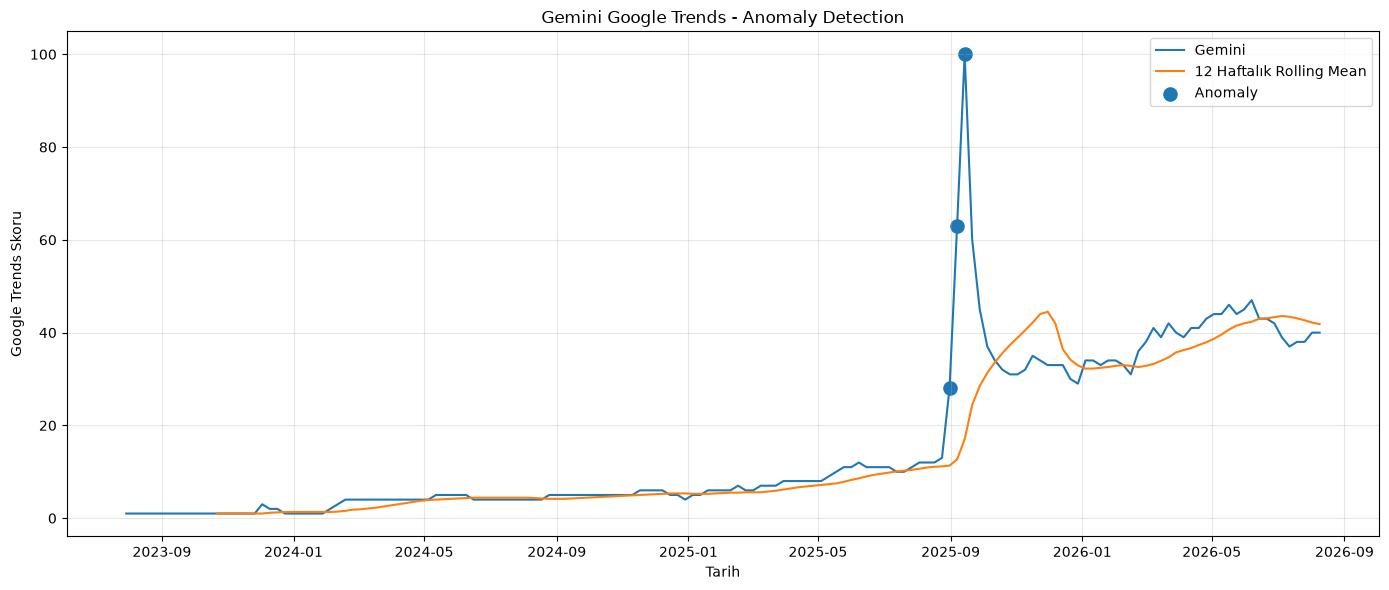

In [12]:
# --------------------------------------------------
# Gemini trendi ve anomaly noktalarının grafiği
# --------------------------------------------------

import matplotlib.pyplot as plt


# Grafik alanını oluşturuyoruz.
#
# figsize:
# Grafiğin genişlik ve yüksekliğini belirler.
plt.figure(
    figsize=(14, 6)
)


# --------------------------------------------------
# Gerçek Gemini serisi
# --------------------------------------------------

# Gemini'nin bütün haftalık değerlerini çiziyoruz.
#
# index -> tarihler
# values -> Google Trends değerleri
plt.plot(
    gemini_series.index,
    gemini_series.values,
    label="Gemini",
)


# --------------------------------------------------
# Rolling mean
# --------------------------------------------------

# Rolling_Mean:
# Her haftadan önceki 12 haftanın ortalama seviyesini gösterir.
#
# Bu çizgi bize sistemin o dönemde neyi
# "normal seviye" olarak gördüğünü gösterir.
plt.plot(
    final_anomaly_result.index,
    final_anomaly_result["Rolling_Mean"],
    label="12 Haftalık Rolling Mean",
)


# --------------------------------------------------
# Anomaly noktaları
# --------------------------------------------------

# scatter():
# Çizgi yerine tek tek noktalar çizer.
#
# Burada yalnızca Is_Anomaly == True olan
# haftaları işaretliyoruz.
plt.scatter(
    detected_anomalies.index,
    detected_anomalies["Value"],
    s=90,
    label="Anomaly",
)


# --------------------------------------------------
# Grafik açıklamaları
# --------------------------------------------------

# Grafiğin başlığı
plt.title(
    "Gemini Google Trends - Anomaly Detection"
)


# X ekseni tarih olduğu için eksen adını yazıyoruz.
plt.xlabel(
    "Tarih"
)


# Y ekseni Google Trends skorunu gösteriyor.
plt.ylabel(
    "Google Trends Skoru"
)


# label verdiğimiz çizgi ve noktaların
# açıklamalarını grafikte gösterir.
plt.legend()


# Arka planda yatay/dikey yardımcı çizgiler oluşturur.
# Grafiği okumayı kolaylaştırır.
plt.grid(
    alpha=0.3
)


# Tarih etiketleri üst üste binmesin diye
# grafiğin yerleşimini otomatik düzenler.
plt.tight_layout()


# Grafiği ekranda gösterir.
plt.show()

#### Early Warning

Şimdi sistemin en güncel haftaya bakıp alarm verip vermediğini otomatik söylemesini sağlayalım:

In [13]:
# --------------------------------------------------
# Current early-warning status
# --------------------------------------------------

# DataFrame'in son satırını alıyoruz.
#
# iloc[-1]:
# "-1" son satır anlamına gelir.
latest_result = final_anomaly_result.iloc[-1]


# Son satırın tarihini ayrıca alıyoruz.
latest_date = final_anomaly_result.index[-1]


# Son haftanın gerçek Gemini değerini alıyoruz.
latest_value = latest_result["Value"]


# Son haftanın anomaly score değerini alıyoruz.
latest_score = latest_result["Anomaly_Score"]


# Son haftanın anomaly olup olmadığını alıyoruz.
#
# True  -> alarm
# False -> normal
latest_is_anomaly = latest_result["Is_Anomaly"]


print(
    "Tarih:",
    latest_date,
)

print(
    "Gemini değeri:",
    latest_value,
)

print(
    "Anomaly Score:",
    latest_score,
)


# "if" koşulu:
#
# latest_is_anomaly True ise ilk blok çalışır.
#
# False ise "else" kısmı çalışır.
if latest_is_anomaly:

    print(
        "⚠️ EARLY WARNING: Olağan dışı trend hareketi tespit edildi."
    )

else:

    print(
        "Normal: Güncel haftada güçlü bir anomaly tespit edilmedi."
    )

Tarih: 2026-08-09 00:00:00
Gemini değeri: 40
Anomaly Score: -0.5424100523573651
Normal: Güncel haftada güçlü bir anomaly tespit edilmedi.


Grafikte üç büyük Gemini hareketi tam istediğimiz gibi işaretlenmiş:

2025-08-31 → 28
2025-09-07 → 63
2025-09-14 → 100

Turuncu 12 Haftalık Rolling Mean çizgisinin spike'tan sonra yavaşça yükseldiğine de dikkat et. Bu normal; rolling mean geçmiş 12 haftayı kullandığı için ani değişime mavi gerçek seri kadar hızlı tepki vermiyor. Zaten anomaly detection'ın işine yarayan şey de bu: gerçek değer bir anda normal kabul edilen seviyeden kopunca bunu görüyoruz.

Güncel çıktı da:

Gemini değeri   = 40
Anomaly Score   = -0.542
Is Anomaly      = False

demek ki sistemin gözünde 9 Ağustos 2026'daki 40 değeri son 12 haftalık davranıştan olağan dışı derecede uzak değil. -0.54 olması yalnızca değerin rolling mean'in biraz altında olduğunu söylüyor; bizim alarm sınırımız ±3.5 olduğu için oldukça normal bölgede.

Şimdi ne yapalım?

Bence artık Gemini üzerinde yeterince çalıştık. Şimdi önemli bir soru var:

Gemini için seçtiğimiz anomaly sistemi ChatGPT ve Claude'da nasıl davranıyor?

Ama dikkat: window=12, threshold=3.5, min_change=5 değerlerini ChatGPT ve Claude için “optimum” ilan etmiyoruz. Sadece aynı prototipi diğer serilere uygularsak ne oluyor diye test edeceğiz.

### Anomaly Detection'ın Diğer Trend Serilerine Uygulanması

Gemini üzerinde geliştirilen anomaly detection prototipi şu parametrelerle
çalışmaktadır:

- `window = 12`
- `threshold = 3.5`
- `min_absolute_change = 5`

Bu parametreler Gemini verisi üzerinde yapılan deneyler sonucunda seçilmiştir.

Bu aşamada aynı yapı ChatGPT ve Claude serilerine de uygulanacaktır.

Amaç, bu parametrelerin diğer trendlerde nasıl davrandığını gözlemlemektir.
Elde edilen sonuçlar ChatGPT ve Claude için bu parametrelerin kesin olarak
uygun olduğu anlamına gelmeyecektir.

In [14]:
# --------------------------------------------------
# Aynı anomaly detector'ı üç trend üzerinde test etme
# --------------------------------------------------

# Analiz etmek istediğimiz üç Google Trends serisini
# bir dictionary içinde topluyoruz.
#
# key:
# Trendin adı
#
# value:
# O trende ait pandas Series
trend_series = {
    "ChatGPT": updated_data["chatgpt"],
    "Gemini": updated_data["gemini"],
    "Claude": updated_data["claude"],
}


# Her trend için oluşan anomaly sonuçlarını
# daha sonra tekrar inceleyebilmek için
# bu dictionary içinde saklayacağız.
all_anomaly_results = {}


# Dictionary içindeki her trendi sırayla geziyoruz.
#
# İlk tur:
# trend_name = "ChatGPT"
# series = ChatGPT zaman serisi
#
# Sonra Gemini ve Claude için aynı işlem yapılacak.
for trend_name, series in trend_series.items():

    # Aynı anomaly detection fonksiyonunu
    # mevcut trend serisine uyguluyoruz.
    result = detect_anomalies(

        # O anda analiz edilen trend serisi
        series=series,

        # Gemini üzerinde seçtiğimiz
        # 12 haftalık geçmiş pencere
        window=12,

        # Anomaly Score sınırı
        threshold=3.5,

        # Mevcut değer ile geçmiş ortalama arasında
        # en az 5 puan fark olmasını istiyoruz.
        min_absolute_change=5,
    )


    # Sonucu trend adına göre saklıyoruz.
    #
    # Örneğin:
    # all_anomaly_results["ChatGPT"]
    #
    # daha sonra ChatGPT sonuçlarını verir.
    all_anomaly_results[trend_name] = result


    # Is_Anomaly == True olan satırları sayıyoruz.
    total_anomalies = (
        result["Is_Anomaly"].sum()
    )


    print(
        f"{trend_name}: {total_anomalies} anomaly"
    )

ChatGPT: 3 anomaly
Gemini: 3 anomaly
Claude: 1 anomaly


### Diğer Trendlerde Tespit Edilen Anomaly Tarihlerinin İncelenmesi

Gemini üzerinde belirlenen anomaly detection parametreleri aynı şekilde
ChatGPT ve Claude serilerine de uygulandı.

Elde edilen toplam anomaly sayıları:

- ChatGPT → 3 anomaly
- Gemini → 3 anomaly
- Claude → 1 anomaly

Bu sonuçlar detector'ın diğer serilerde aşırı sayıda alarm üretmediğini
göstermektedir.

Ancak yalnızca toplam anomaly sayısı yeterli değildir.

Bir anomaly detection sisteminin anlamlı olup olmadığını değerlendirmek için
hangi tarihlerde alarm verdiği ve bu tarihlerde zaman serisinin gerçekten
olağan dışı bir davranış gösterip göstermediği incelenmelidir.

Bu nedenle bir sonraki adımda her trend için tespit edilen anomaly tarihleri,
gerçek değerler ve anomaly skorları karşılaştırılacaktır.

In [15]:
# --------------------------------------------------
# Her trend için anomaly tarihlerini inceleme
# --------------------------------------------------

# all_anomaly_results sözlüğünde daha önce:
#
# all_anomaly_results["ChatGPT"]
# all_anomaly_results["Gemini"]
# all_anomaly_results["Claude"]
#
# şeklinde üç trendin anomaly sonuçlarını saklamıştık.


# Dictionary içindeki her trendi sırayla geziyoruz.
#
# trend_name:
# "ChatGPT", "Gemini" veya "Claude"
#
# result:
# O trende ait anomaly detection DataFrame'i
for trend_name, result in all_anomaly_results.items():

    # Sadece Is_Anomaly == True olan satırları seçiyoruz.
    #
    # Böylece normal haftalar yerine yalnızca
    # sistemin alarm verdiği haftaları görüyoruz.
    anomalies = result.loc[
        result["Is_Anomaly"]
    ]


    # Hangi trendin sonuçlarını gösterdiğimizi
    # ekrana yazdırıyoruz.
    print(
        f"\n{trend_name} ANOMALIES"
    )


    # Her anomaly için:
    #
    # Value
    # -> O haftanın gerçek Google Trends değeri
    #
    # Rolling_Mean
    # -> Önceki 12 haftanın ortalama seviyesi
    #
    # Absolute_Change
    # -> Gerçek değer ile geçmiş ortalama arasındaki fark
    #
    # Anomaly_Score
    # -> Değerin geçmiş davranıştan kaç standart sapma
    #    uzak olduğunu gösterir
    display(
        anomalies[
            [
                "Value",
                "Rolling_Mean",
                "Absolute_Change",
                "Anomaly_Score",
            ]
        ]
    )


ChatGPT ANOMALIES


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2023-12-24,14,20.750000,6.750000,-4.369537
2025-03-30,83,47.833333,35.166667,7.696239
2025-12-21,57,81.083333,24.083333,-5.374013



Gemini ANOMALIES


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2025-08-31,28,11.333333,16.666667,18.776690
2025-09-07,63,12.666667,50.333333,10.261301
2025-09-14,100,17.000000,83.000000,5.430101



Claude ANOMALIES


,Value,Rolling_Mean,Absolute_Change,Anomaly_Score
date,,,,
2026-03-01,14,5.416667,8.583333,3.708798


Şimdi sonuç bayağı anlamlı görünüyor. Aynı detector’ı üç seriye uygulayınca sadece Gemini’de değil, ChatGPT ve Claude’da da belirgin kırılmaları yakalamış.

Üstteki ilk tablo **ChatGPT** sonuçları:

```text
2023-12-24 → Value 14,  Rolling Mean 20.75,  Score -4.37
2025-03-30 → Value 83,  Rolling Mean 47.83,  Score +7.70
2025-12-21 → Value 57,  Rolling Mean 81.08,  Score -5.37
```

Burada işaretin anlamı önemli:

```text
+ anomaly score → beklenmedik yükseliş
- anomaly score → beklenmedik düşüş
```

Mesela `2025-03-30` çok net bir **yukarı yönlü anomaly**. ChatGPT o haftada `83`, halbuki önceki 12 haftalık ortalama yaklaşık `47.8`. Aradaki fark yaklaşık `35 puan`. Detector bu yüzden `+7.70` gibi çok güçlü bir skor vermiş.

`2025-12-21` ise tam tersi. Normal seviye yaklaşık `81`, gerçek değer `57`. Yaklaşık `24 puanlık` aşağı yönlü kırılma var. Bu yüzden skor `-5.37`.

Gemini zaten bildiğimiz örnek:

```text
28  → score 18.78
63  → score 10.26
100 → score  5.43
```

Bu üçü ardışık biçimde aynı büyük trend şokunu gösteriyor.

Claude’da ise:

```text
2026-03-01
Value          = 14
Rolling Mean   = 5.42
Absolute Change= 8.58
Anomaly Score  = 3.71
```

Burada da Claude’un o dönemde yakın geçmişine göre ani bir yükselişi var ama Gemini kadar uç bir şok değil.

### Veri analisti olarak şu anda ne söyleyebiliriz?

Bence önemli sonuç şu:

> Gemini üzerinde seçtiğimiz `window=12`, `threshold=3.5`, `min_absolute_change=5` kombinasyonu diğer iki seride de yüzlerce gereksiz alarm üretmedi.

Bu iyi bir işaret. Ama henüz:

> “Bu parametreler bütün teknoloji trendleri için optimumdur.”

diyemeyiz.

Çünkü ChatGPT’deki bu üç tarihin ve Claude’daki tarihin gerçekten anlamlı olaylarla örtüşüp örtüşmediğini henüz kontrol etmedik.

Şu anda detector bize aslında **araştırılması gereken tarihleri daralttı**:

```text
ChatGPT
→ 2023-12-24
→ 2025-03-30
→ 2025-12-21

Gemini
→ 2025-08-31
→ 2025-09-07
→ 2025-09-14

Claude
→ 2026-03-01
```

Bu anomaly detection’ın gerçek faydalarından biri zaten: 3 yıllık haftalık veride tek tek 150+ haftaya bakmak yerine, sistem “şu 7 haftaya özellikle bak” diyor.

### Bence sıradaki adım

Şimdi **event validation** yapalım. Yani bu tarihler civarında gerçekten önemli bir ürün duyurusu, model çıkışı veya başka büyük olay olmuş mu araştıracağız.

Böylece iki farklı şeyi ayırabiliriz:

```text
İstatistiksel anomaly
        ↓
Gerçek dış olayla örtüşüyor mu?
        ↓
Evet → anlamlı trend shock
Hayır → olası false alarm / başka açıklama
```

Bu kısım için web’de tarihleri araştırmak gerekir. Özellikle ilk etapta ChatGPT’nin `2025-03-30`, `2025-12-21` ve Claude’un `2026-03-01` tarihlerini incelemek bence güzel olur. Gemini’nin büyük spike’ının dış olaylarla ilişkisini zaten daha önce konuşmuştuk.

İstersen şimdi bunu yapalım: **bu dört yeni anomaly tarihinin ±1 haftasında neler olmuş web’den araştırıp küçük bir “event validation” tablosu çıkaralım.**


### Event Validation

Araştırdım; burada güzel bir ayrım çıktı: **bazı anomaly’lerin dış olaylarla bağı çok güçlü, bazıları ise daha çok mevsimsellik/usage pattern gibi görünüyor.**

| Trend / Anomaly                 | Yakındaki olay                                                                                                                                                                                                                                                                                               | Yorum                                                                                                                                                                                                                                                                                                            | Güven           |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------- |
| **ChatGPT — 2025-03-30, +7.70** | OpenAI 25 Mart’ta GPT-4o native image generation’ı ChatGPT’ye çıkardı. Hemen ardından Ghibli tarzı görseller viral oldu. Sensor Tower, 24 Mart ve 31 Mart haftalarında ChatGPT kullanımının ciddi biçimde sıçradığını ve haftalık aktif kullanıcıların rekor seviyelere ulaştığını bildirdi. ([OpenAI][1])   | **Çok güçlü event match.** `47.8 → 83` sıçramasının bu lansman/viral dalgayla ilişkili olması oldukça makul. Nedenselliği yine kesin kanıtlamıyoruz.                                                                                                                                                             | **Yüksek**      |
| **Claude — 2026-03-01, +3.71**  | Anthropic 17 Şubat’ta Sonnet 4.6’yı çıkardı ve Claude.ai’de varsayılan modele dönüştürdü. Ayrıca 23–27 Şubat haftasında Anthropic hakkında distillation saldırıları, Vercept satın alımı ve özellikle ABD Savunma Bakanlığı ile yaşanan yüksek profilli tartışmalar peş peşe gündeme geldi. ([Anthropic][2]) | Tek bir olaydan ziyade **yoğun bir haber/ürün dönemi** Claude aramalarını artırmış olabilir.                                                                                                                                                                                                                     | **Orta-yüksek** |
| **ChatGPT — 2025-12-21, −5.37** | Aslında o haftanın hemen öncesinde GPT-5.2, yeni ChatGPT Images ve App Directory gibi ürün güncellemeleri vardı. ([OpenAI Help Center][3])                                                                                                                                                                   | Negatif anomaly’yi bir ürün kötüleşmesiyle açıklamak zor. Christmas döneminde ChatGPT trafiğinin ciddi düştüğüne dair Similarweb tabanlı veri var; bu yüzden **yıl sonu/holiday seasonality** daha makul bir aday. Ancak anomaly haftası 21 Aralık’ta bittiği için bunu kesin eşleştirmiyoruz. ([OfficeChai][4]) | **Orta-düşük**  |
| **ChatGPT — 2023-12-24, −4.37** | Bu tarihin hemen çevresinde güçlü bir ChatGPT ürün olayı bulamadım. Ancak Cloudflare’ın 2023 verilerinde Noel arifesi ve Noel günü birçok ülkede genel internet trafiğinde belirgin düşüşler görülmüş; ABD’de de 24–25 Aralık düşüşleri raporlanmış. ([Cloudflare Blog][5])                                  | Burada da **holiday seasonality** mantıklı bir açıklama, fakat ChatGPT’ye özel doğrudan kanıtımız yok.                                                                                                                                                                                                           | **Düşük-orta**  |

Buradan veri analisti olarak çıkaracağımız en önemli sonuç şu: **Anomaly detector bir olayın nedenini söylemiyor.** Sadece “bu tarihe bak” diyor. Sonra biz dış veriyle validation yapıyoruz.

Örneğin 30 Mart 2025 için zincirimiz oldukça güçlü:

```text
Anomaly detector
        ↓
2025-03-30 olağan dışı yükseliş
        ↓
Dış kaynak araştırması
        ↓
25 Mart: GPT-4o image generation
        ↓
Viral Ghibli trendi + kullanım sıçraması
        ↓
Strong event association ✅
```

Ama 24 Aralık 2023 için:

```text
Anomaly detector
        ↓
Olağan dışı düşüş
        ↓
Belirgin ürün olayı yok
        ↓
Genel holiday traffic düşüşü var
        ↓
Possible seasonality ⚠️
```

Yani **“anomaly = kesin dış olay” demiyoruz.** Bu ayrım raporda da önemli olacak.

Bence şimdi notebook’ta küçük bir **event-validation tablosu** oluşturalım. Böylece bu araştırmayı kafamızda bırakmayız:

```python

Bu tablo ileride **event-aware forecasting** tarafına geçerken de çok işimize yarayabilir. Ama orada doğrudan “event olmuş, modele 1 yaz” demeden önce hangi event bilgisinin tahmin anında gerçekten bilinebilir olduğunu ayrıca ayıracağız.


In [16]:
# --------------------------------------------------
# Anomaly Event Validation
# --------------------------------------------------

# Anomaly detection sonucunda bulunan önemli tarihleri
# dış olaylarla karşılaştırarak manuel olarak etiketliyoruz.
#
# Bu tablo model tarafından otomatik üretilmiyor.
# Web araştırması ve analist değerlendirmesiyle oluşturuluyor.
event_validation = pd.DataFrame(
    [
        {
            # Anomaly'nin ait olduğu trend
            "Trend": "ChatGPT",

            # Detector'ın anomaly olarak işaretlediği hafta
            "Anomaly_Date": "2025-03-30",

            # Pozitif skor -> yukarı yönlü anomaly
            "Direction": "Up",

            # Yakındaki olası dış olay
            "Candidate_Event": (
                "GPT-4o image generation launch "
                "and viral image-generation trend"
            ),

            # Dış olay ile anomaly arasındaki ilişkinin
            # ne kadar güçlü göründüğüne dair analist değerlendirmesi
            "Confidence": "High",
        },
        {
            "Trend": "Claude",
            "Anomaly_Date": "2026-03-01",
            "Direction": "Up",
            "Candidate_Event": (
                "Sonnet 4.6 release and intensive "
                "Anthropic news cycle"
            ),
            "Confidence": "Medium-High",
        },
        {
            "Trend": "ChatGPT",
            "Anomaly_Date": "2025-12-21",
            "Direction": "Down",
            "Candidate_Event": (
                "Possible holiday-season usage effect"
            ),
            "Confidence": "Medium-Low",
        },
        {
            "Trend": "ChatGPT",
            "Anomaly_Date": "2023-12-24",
            "Direction": "Down",
            "Candidate_Event": (
                "Possible holiday-season usage effect"
            ),
            "Confidence": "Low-Medium",
        },
    ]
)


# Tarih sütununu string yerine gerçek datetime tipine çeviriyoruz.
#
# Böylece ileride anomaly sonuçlarıyla tarih üzerinden
# birleştirmek veya filtrelemek daha kolay olacak.
event_validation["Anomaly_Date"] = pd.to_datetime(
    event_validation["Anomaly_Date"]
)


display(event_validation)



,Trend,Anomaly_Date,Direction,Candidate_Event,Confidence
0,ChatGPT,2025-03-30,Up,GPT-4o image generation launch and viral image...,High
1,Claude,2026-03-01,Up,Sonnet 4.6 release and intensive Anthropic new...,Medium-High
2,ChatGPT,2025-12-21,Down,Possible holiday-season usage effect,Medium-Low
3,ChatGPT,2023-12-24,Down,Possible holiday-season usage effect,Low-Medium


### Anomaly Sonuçlarının Dış Olaylarla Birleştirilmesi

Anomaly detection sonucunda tespit edilen bazı önemli tarihler dış gelişmelerle
manuel olarak karşılaştırıldı.

Bu aşamada anomaly detection sonuçları ile event validation bilgileri
birleştirilecektir.

Amaç, tek bir tabloda:

- anomaly tarihi,
- trend adı,
- gerçek Google Trends değeri,
- anomaly score,
- anomaly yönü,
- olası dış olay,
- olay-anomaly ilişkisinin güven seviyesi

bilgilerini birlikte görebilmektir.

Bu tablo anomaly detection modelinin bir olayın nedenini otomatik olarak
bulduğu anlamına gelmez. Dış olay bilgileri analist tarafından yapılan
araştırma sonucunda eklenmektedir.

In [17]:
# --------------------------------------------------
# Anomaly sonuçları ile event validation'ı birleştirme
# --------------------------------------------------

# Üç trendin anomaly sonuçlarını tek tabloda
# birleştirebilmek için boş bir liste oluşturuyoruz.
#
# Her trend için oluşturduğumuz küçük DataFrame'leri
# bu listeye ekleyeceğiz.
anomaly_tables = []


# all_anomaly_results sözlüğünün içinde:
#
# "ChatGPT" -> ChatGPT anomaly sonuçları
# "Gemini"  -> Gemini anomaly sonuçları
# "Claude"  -> Claude anomaly sonuçları
#
# bulunuyor.
#
# .items() bize hem trend adını
# hem de o trende ait DataFrame'i verir.
for trend_name, result in all_anomaly_results.items():

    # Sadece anomaly olarak işaretlenen haftaları seçiyoruz.
    #
    # .copy() kullanmamızın nedeni:
    # seçtiğimiz DataFrame üzerinde yeni sütunlar eklerken
    # orijinal result DataFrame'ini değiştirmemek.
    anomalies = result.loc[
        result["Is_Anomaly"]
    ].copy()


    # Hangi anomaly'nin hangi trende ait olduğunu
    # daha sonra kaybetmemek için Trend sütunu ekliyoruz.
    anomalies["Trend"] = trend_name


    # Tarih şu anda DataFrame index'i durumunda.
    #
    # reset_index() ile tarihi normal bir sütuna çeviriyoruz.
    anomalies = anomalies.reset_index()


    # Tarih sütununun adını event_validation tablosuyla
    # aynı hale getiriyoruz.
    #
    # Böylece iki tabloyu tarih üzerinden
    # kolayca birleştirebiliriz.
    anomalies = anomalies.rename(
        columns={
            "date": "Anomaly_Date",
            "Value": "Actual_Value",
        }
    )


    # Hazırlanan trend tablosunu listeye ekliyoruz.
    anomaly_tables.append(
        anomalies
    )


# --------------------------------------------------
# Üç trendin anomaly tablolarını birleştirme
# --------------------------------------------------

# pd.concat():
# Liste içindeki DataFrame'leri alt alta birleştirir.
#
# ignore_index=True:
# eski index numaralarını kullanmak yerine
# yeni 0, 1, 2... index'i oluşturur.
all_detected_anomalies = pd.concat(
    anomaly_tables,
    ignore_index=True,
)


# --------------------------------------------------
# Event validation bilgilerini ekleme
# --------------------------------------------------

# pd.merge():
# İki tabloyu ortak sütunlar üzerinden birleştirir.
#
# Burada iki ortak bilgi kullanıyoruz:
#
# Trend
# Anomaly_Date
#
# Böylece örneğin:
# ChatGPT + 2025-03-30
#
# anomaly sonucu ile o tarih için araştırdığımız
# dış olay bilgisi eşleştirilir.
#
# how="left":
# bütün anomaly satırlarını korur.
#
# Eğer bazı anomaly'ler için henüz dış olay araştırmadıysak
# Candidate_Event ve Confidence alanları NaN kalır.
anomaly_event_summary = pd.merge(
    all_detected_anomalies,
    event_validation,
    on=[
        "Trend",
        "Anomaly_Date",
    ],
    how="left",
)


# --------------------------------------------------
# İncelemek istediğimiz sütunları seçme
# --------------------------------------------------

anomaly_event_summary = anomaly_event_summary[
    [
        "Trend",
        "Anomaly_Date",
        "Actual_Value",
        "Rolling_Mean",
        "Absolute_Change",
        "Anomaly_Score",
        "Direction",
        "Candidate_Event",
        "Confidence",
    ]
]


# Tarihe göre sıralıyoruz.
anomaly_event_summary = (
    anomaly_event_summary
    .sort_values(
        by="Anomaly_Date"
    )
    .reset_index(drop=True)
)


display(
    anomaly_event_summary
)

,Trend,Anomaly_Date,Actual_Value,Rolling_Mean,Absolute_Change,Anomaly_Score,Direction,Candidate_Event,Confidence
0,ChatGPT,2023-12-24,14,20.750000,6.750000,-4.369537,Down,Possible holiday-season usage effect,Low-Medium
1,ChatGPT,2025-03-30,83,47.833333,35.166667,7.696239,Up,GPT-4o image generation launch and viral image...,High
2,Gemini,2025-08-31,28,11.333333,16.666667,18.776690,NaN,NaN,NaN
3,Gemini,2025-09-07,63,12.666667,50.333333,10.261301,NaN,NaN,NaN
4,Gemini,2025-09-14,100,17.000000,83.000000,5.430101,NaN,NaN,NaN
5,ChatGPT,2025-12-21,57,81.083333,24.083333,-5.374013,Down,Possible holiday-season usage effect,Medium-Low
6,Claude,2026-03-01,14,5.416667,8.583333,3.708798,Up,Sonnet 4.6 release and intensive Anthropic new...,Medium-High


### Event-Aware Forecasting'e Giriş

Normal forecasting modellerimiz büyük ölçüde geçmiş trend değerlerinden öğrenmektedir.

Örneğin XGBoost modelimiz:

- geçmiş haftaların değerlerini (`lag_1` ... `lag_8`),
- son haftalardaki değişimleri (`change_1`, `change_2`)

kullanarak gelecek haftayı tahmin etmektedir.

Ancak gerçek dünyadaki trendler yalnızca geçmiş değerlere bağlı değildir.

Ürün lansmanları, büyük duyurular, viral gelişmeler veya önemli haberler
arama ilgisinde ani değişimlere neden olabilir.

Bu nedenle event-aware forecasting yaklaşımında modele yalnızca geçmiş trend
değerleri değil, dış olaylarla ilgili ek bilgiler de verilebilir.

Örneğin:

- `event_occurred`
- `weeks_since_event`
- `major_product_launch`

gibi feature'lar oluşturulabilir.

Ancak burada data leakage açısından önemli bir kural vardır:

> Bir tahmin oluşturulurken yalnızca o tarihte gerçekten bilinebilecek olay
> bilgileri kullanılmalıdır.

Örneğin bir olay önceden bilinmiyorsa, olay gerçekleşmeden önceki bir tahmine
bu olayın bilgisi eklenemez.

Bu nedenle ilk aşamada event bilgileri doğrudan modele verilmeden önce
zaman serisi ile olay tarihleri arasındaki ilişki incelenecektir.

In [18]:
# --------------------------------------------------
# Gemini için ilk external event tablosu
# --------------------------------------------------

# Bu tablo Google Trends verisinin kendisinden gelmiyor.
#
# Dış kaynak araştırması sonucunda bildiğimiz olayları
# ayrı bir veri kaynağı olarak saklıyoruz.
#
# Böyle bir tabloya ileride birden fazla:
# - model lansmanı
# - önemli ürün duyurusu
# - büyük özellik çıkışı
# eklenebilir.
gemini_events = pd.DataFrame(
    [
        {
            # Olayın gerçekleştiği tarih
            "event_date": "2025-08-26",

            # Olayın kısa adı
            "event_name": "Gemini 2.5 Flash Image launch",

            # Olayın genel kategorisi
            "event_type": "product_launch",
        }
    ]
)


# event_date şu anda metin (string) durumunda.
#
# pd.to_datetime() ile gerçek tarih tipine çeviriyoruz.
#
# Böylece daha sonra Google Trends tarihleriyle
# matematiksel olarak karşılaştırabiliriz.
gemini_events["event_date"] = pd.to_datetime(
    gemini_events["event_date"]
)


display(
    gemini_events
)

,event_date,event_name,event_type
0,2025-08-26,Gemini 2.5 Flash Image launch,product_launch


In [19]:
# --------------------------------------------------
# Event tarihinin haftalık trend verisindeki konumunu bulma
# --------------------------------------------------

# İlk event'in tarihini alıyoruz.
#
# iloc[0]:
# tablonun ilk satırı anlamına gelir.
event_date = gemini_events.iloc[0][
    "event_date"
]


# Gemini verimiz haftalık ve tarihler Pazar günlerini temsil ediyor.
#
# Event 26 Ağustos 2025 Salı günü gerçekleşti.
#
# Şimdi event'ten SONRA gelen ilk haftalık
# Google Trends gözlemini bulmak istiyoruz.
#
# index >= event_date:
# event tarihi veya sonrasındaki haftaları True yapar.
#
# [0]:
# bunların içinden ilk tarihi seçer.
first_week_after_event = gemini_series.index[
    gemini_series.index >= event_date
][0]


print(
    "Event tarihi:",
    event_date,
)

print(
    "Event sonrası ilk haftalık gözlem:",
    first_week_after_event,
)

print(
    "O haftadaki Gemini değeri:",
    gemini_series.loc[first_week_after_event],
)

Event tarihi: 2025-08-26 00:00:00
Event sonrası ilk haftalık gözlem: 2025-08-31 00:00:00
O haftadaki Gemini değeri: 28


### Event Feature Oluşturma

Gemini zaman serisine dış olay bilgisini temsil eden yeni feature'lar eklenecektir.

İlk aşamada iki feature kullanılacaktır:

- `event_occurred`
- `weeks_since_event`

`event_occurred`, ilgili haftanın bir dış olaydan sonraki ilk haftalık gözlem olup
olmadığını gösterir.

`weeks_since_event` ise olaydan sonra kaç hafta geçtiğini belirtir.

Bu feature'ların amacı, forecasting modeline yalnızca geçmiş trend değerlerini
değil, zaman serisini etkileyebilecek dış olayların zamanlamasını da
aktarabilmektir.

Ancak bu bilgiler yalnızca tahmin anında gerçekten biliniyorsa kullanılmalıdır.
Aksi halde gelecekteki bilgiyi geçmiş tahminlere taşımak data leakage oluşturur.

In [20]:
# --------------------------------------------------
# Gemini event feature'larını oluşturma
# --------------------------------------------------

# Gemini zaman serisini temel alan yeni bir DataFrame oluşturuyoruz.
#
# Burada her satır bir haftayı temsil edecek.
event_feature_data = pd.DataFrame(
    {
        "gemini": gemini_series
    }
)


# --------------------------------------------------
# 1. Event'in haftalık verideki tarihini belirleme
# --------------------------------------------------

# Daha önce bulduğumuz event sonrası ilk haftalık gözlem:
#
# 2025-08-31
#
# Olay 2025-08-26 tarihinde gerçekleşmişti,
# ancak bizim trend verimiz haftalık olduğu için
# event'i 2025-08-31 haftasıyla eşleştiriyoruz.
event_week = first_week_after_event


# --------------------------------------------------
# 2. event_occurred feature'ı
# --------------------------------------------------

# Başlangıçta bütün haftalarda event yok kabul ediyoruz.
#
# 0 -> Bu hafta event ile eşleşmiyor.
# 1 -> Bu hafta event sonrası ilk haftalık gözlem.
event_feature_data["event_occurred"] = 0


# .loc ile sadece event_week satırını seçiyoruz.
#
# O haftada event_occurred değerini 1 yapıyoruz.
event_feature_data.loc[
    event_week,
    "event_occurred"
] = 1


# --------------------------------------------------
# 3. weeks_since_event feature'ı
# --------------------------------------------------

# Başlangıçta bütün haftalara NaN veriyoruz.
#
# NaN burada:
# "Bu hafta için event sonrası geçen hafta sayısı
# henüz geçerli değil."
#
# anlamında kullanılacak.
event_feature_data["weeks_since_event"] = np.nan


# Event haftasından itibaren hangi satırların
# kullanılacağını belirliyoruz.
#
# index >= event_week:
# event haftası ve sonrasındaki bütün haftaları seçer.
after_event_mask = (
    event_feature_data.index >= event_week
)


# Event haftası ve sonraki haftaları ayrı bir index olarak alıyoruz.
after_event_dates = (
    event_feature_data.index[
        after_event_mask
    ]
)


# range(len(after_event_dates)):
#
# 0, 1, 2, 3, 4...
#
# şeklinde sayı üretir.
#
# Böylece:
#
# event haftası      -> 0
# 1 hafta sonrası    -> 1
# 2 hafta sonrası    -> 2
# 3 hafta sonrası    -> 3
#
# şeklinde ilerleyen bir feature oluşturuyoruz.
event_feature_data.loc[
    after_event_mask,
    "weeks_since_event"
] = range(
    len(after_event_dates)
)


# Sonucu event çevresindeki tarihler için gösteriyoruz.
display(
    event_feature_data.loc[
        "2025-08-10":"2025-10-05"
    ]
)

,gemini,event_occurred,weeks_since_event
date,,,
2025-08-10,12,0,NaN
2025-08-17,12,0,NaN
2025-08-24,13,0,NaN
2025-08-31,28,1,0.0
2025-09-07,63,0,1.0
2025-09-14,100,0,2.0
2025-09-21,60,0,3.0
2025-09-28,45,0,4.0
2025-10-05,37,0,5.0


### Event-Aware XGBoost Veri Setinin Hazırlanması

Mevcut XGBoost modeli geçmiş trend davranışını temsil eden şu feature'ları
kullanmaktadır:

- `lag_1` ... `lag_8`
- `change_1`
- `change_2`

Bu aşamada Gemini için oluşturulan dış olay bilgileri de feature setine
eklenecektir:

- `event_occurred`
- `weeks_since_event`

Böylece model yalnızca geçmiş Google Trends değerlerini değil, bilinen bir dış
olayın zamanlamasını da görebilecektir.

Ancak yalnızca tek bir event örneği bulunduğu için bu deneyin sonucu dikkatli
yorumlanmalıdır. Event feature'larının modele eklenmesi performansın kesin olarak
iyileşeceği anlamına gelmez.

Ayrıca event bilgisi yalnızca tahmin anında gerçekten bilinebiliyorsa
kullanılabilir. Bu kural data leakage oluşmasını önlemek için korunacaktır.

In [21]:
# --------------------------------------------------
# Event-aware XGBoost veri setini hazırlama
# --------------------------------------------------

# XGBoost modelimizde daha önce 8 haftalık geçmiş
# kullanmıştık.
#
# Bu nedenle yine aynı yapıyı koruyoruz.
N_LAGS = 8


# Yeni bir DataFrame oluşturuyoruz.
#
# "target":
# Modelin tahmin etmeye çalışacağı gerçek Gemini değeri.
event_xgb_data = pd.DataFrame(
    {
        "target": gemini_series
    }
)


# --------------------------------------------------
# Lag feature'larını oluşturma
# --------------------------------------------------

# range(1, N_LAGS + 1):
#
# N_LAGS = 8 olduğu için:
#
# 1, 2, 3, 4, 5, 6, 7, 8
#
# sayılarını sırayla üretir.
for lag in range(1, N_LAGS + 1):

    # shift(lag):
    # Gemini serisini belirtilen hafta kadar aşağı kaydırır.
    #
    # Örneğin:
    #
    # lag_1 -> bir önceki haftanın Gemini değeri
    # lag_2 -> iki hafta önceki değer
    # ...
    # lag_8 -> sekiz hafta önceki değer
    event_xgb_data[
        f"lag_{lag}"
    ] = gemini_series.shift(lag)


# --------------------------------------------------
# Change feature'larını oluşturma
# --------------------------------------------------

# Son iki haftanın değerleri arasındaki değişim.
#
# Örneğin:
#
# lag_1 = 63
# lag_2 = 28
#
# change_1 = 63 - 28 = 35
event_xgb_data["change_1"] = (
    event_xgb_data["lag_1"]
    - event_xgb_data["lag_2"]
)


# Bir önceki değişim.
#
# Böylece model sadece son değişimi değil,
# ondan önceki hareketi de görebiliyor.
event_xgb_data["change_2"] = (
    event_xgb_data["lag_2"]
    - event_xgb_data["lag_3"]
)


# --------------------------------------------------
# Event feature'larını ekleme
# --------------------------------------------------

# Daha önce event_feature_data içinde oluşturduğumuz
# event_occurred sütununu buraya ekliyoruz.
#
# Aynı tarih index'ini kullandıkları için pandas
# tarihleri otomatik olarak eşleştirir.
event_xgb_data["event_occurred"] = (
    event_feature_data["event_occurred"]
)


# Event sonrasında kaç hafta geçtiğini gösteren
# feature'ı da ekliyoruz.
event_xgb_data["weeks_since_event"] = (
    event_feature_data["weeks_since_event"]
)


# --------------------------------------------------
# İlk 8 haftadaki eksik lag değerlerini temizleme
# --------------------------------------------------

# İlk haftalarda lag_8 gibi feature'lar hesaplanamaz.
#
# Örneğin serinin ilk haftasında:
# "8 hafta önceki değer" yoktur.
#
# Bu nedenle lag feature'larından kaynaklanan
# eksik satırları kaldırıyoruz.
#
# subset kullanmamız önemli:
# weeks_since_event içindeki NaN değerleri şu anda
# kaldırmak istemiyoruz.
lag_columns = [
    f"lag_{lag}"
    for lag in range(1, N_LAGS + 1)
]


event_xgb_data = (
    event_xgb_data
    .dropna(
        subset=lag_columns
    )
)


# Event çevresindeki dönemi gösteriyoruz.
display(
    event_xgb_data.loc[
        "2025-08-10":"2025-10-05"
    ]
)

,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,change_1,change_2,event_occurred,weeks_since_event
date,,,,,,,,,,,,,
2025-08-10,12,12.0,11.0,10.0,10.0,11.0,11.0,11.0,11.0,1.0,1.0,0,NaN
2025-08-17,12,12.0,12.0,11.0,10.0,10.0,11.0,11.0,11.0,0.0,1.0,0,NaN
2025-08-24,13,12.0,12.0,12.0,11.0,10.0,10.0,11.0,11.0,0.0,0.0,0,NaN
2025-08-31,28,13.0,12.0,12.0,12.0,11.0,10.0,10.0,11.0,1.0,0.0,1,0.0
2025-09-07,63,28.0,13.0,12.0,12.0,12.0,11.0,10.0,10.0,15.0,1.0,0,1.0
2025-09-14,100,63.0,28.0,13.0,12.0,12.0,12.0,11.0,10.0,35.0,15.0,0,2.0
2025-09-21,60,100.0,63.0,28.0,13.0,12.0,12.0,12.0,11.0,37.0,35.0,0,3.0
2025-09-28,45,60.0,100.0,63.0,28.0,13.0,12.0,12.0,12.0,-40.0,37.0,0,4.0
2025-10-05,37,45.0,60.0,100.0,63.0,28.0,13.0,12.0,12.0,-15.0,-40.0,0,5.0


Ama burada önemli bir sorun var

weeks_since_event şu anda event’ten önce NaN, event’ten sonra ise:

0, 1, 2, 3, ... 40, 41, 42...

diye sonsuza kadar büyüyor.

Bu bize pek istediğimiz şeyi anlatmıyor. 30 hafta önce gerçekleşmiş bir ürün lansmanının hâlâ “event etkisi” varmış gibi modele sayı vermek istemeyebiliriz.

Bu yüzden şimdi event etkisini örneğin ilk 4 hafta ile sınırlandıran daha anlamlı bir feature oluşturalım:

In [22]:
# --------------------------------------------------
# Event active feature'ı oluşturma
# --------------------------------------------------

# EVENT_EFFECT_WEEKS:
# Bir dış olayın etkisini kaç hafta boyunca
# aktif kabul edeceğimizi belirleyen parametre.
#
# Şimdilik başlangıç deneyi olarak 4 hafta seçiyoruz.
# Bu değerin kesin optimum olduğunu söylemiyoruz.
EVENT_EFFECT_WEEKS = 4


# event_active:
#
# 1 -> event sonrası ilk 4 haftanın içindeyiz
# 0 -> event öncesindeyiz veya olayın üzerinden
#      4 haftadan fazla zaman geçti
#
# .between(0, 3):
# 0, 1, 2 veya 3 değerlerinde True verir.
#
# astype(int):
# True  -> 1
# False -> 0
#
# dönüşümünü yapar.
event_xgb_data["event_active"] = (
    event_xgb_data["weeks_since_event"]
    .between(
        0,
        EVENT_EFFECT_WEEKS - 1,
    )
    .astype(int)
)


display(
    event_xgb_data.loc[
        "2025-08-10":"2025-10-05",
        [
            "target",
            "event_occurred",
            "weeks_since_event",
            "event_active",
        ],
    ]
)

,target,event_occurred,weeks_since_event,event_active
date,,,,
2025-08-10,12,0,NaN,0
2025-08-17,12,0,NaN,0
2025-08-24,13,0,NaN,0
2025-08-31,28,1,0.0,1
2025-09-07,63,0,1.0,1
2025-09-14,100,0,2.0,1
2025-09-21,60,0,3.0,1
2025-09-28,45,0,4.0,0
2025-10-05,37,0,5.0,0


Devam edelim ama burada önemli bir metodolojik nokta var: tek bir event ile event-aware XGBoost’u gerçekten eğitip değerlendirmek sağlıklı değil.

Şu an elimizde yalnızca 26 Ağustos 2025’teki Gemini 2.5 Flash Image olayı var. Eğer modeli bu olaydan önceki verilerle eğitirsek, training set içinde:

event_active = 1

olan hiç örnek bulunmayacak. Model sadece event_active = 0 görmüş olacak. Bu durumda 1 değerinin trend üzerinde ne anlama geldiğini öğrenemez.

Önce bunu kendi verimizde kanıtlayalım.

In [23]:
# --------------------------------------------------
# Event feature training set içinde gerçekten var mı?
# --------------------------------------------------

# İncelediğimiz event'in haftalık verideki karşılığı:
# 2025-08-31
EVENT_WEEK = pd.Timestamp(
    "2025-08-31"
)


# Event haftasından ÖNCEKİ bütün satırları seçiyoruz.
#
# Bu, 2025-08-31 haftasını tahmin etmek için
# teorik olarak elimizde bulunabilecek geçmiş veriyi temsil ediyor.
training_before_event = event_xgb_data.loc[
    event_xgb_data.index < EVENT_WEEK
]


# Event haftası ve hemen sonrasındaki dönemi
# ayrıca incelemek için seçiyoruz.
event_period = event_xgb_data.loc[
    "2025-08-31":"2025-09-21"
]


# --------------------------------------------------
# Training set içindeki event_active dağılımı
# --------------------------------------------------

# value_counts():
# Bir sütundaki her farklı değerin kaç kez geçtiğini sayar.
#
# Eğer burada yalnızca:
#
# 0    ...
#
# görürsek, model training sırasında hiç event_active=1
# örneği görmemiş demektir.
print(
    "Event öncesi training setindeki event_active değerleri:"
)

display(
    training_before_event[
        "event_active"
    ].value_counts()
)


# --------------------------------------------------
# Event dönemini gösterme
# --------------------------------------------------

print(
    "\nEvent dönemindeki feature'lar:"
)

display(
    event_period[
        [
            "target",
            "event_occurred",
            "weeks_since_event",
            "event_active",
        ]
    ]
)

Event öncesi training setindeki event_active değerleri:


event_active
0    101
Name: count, dtype: int64


Event dönemindeki feature'lar:


,target,event_occurred,weeks_since_event,event_active
date,,,,
2025-08-31,28,1,0.0,1
2025-09-07,63,0,1.0,1
2025-09-14,100,0,2.0,1
2025-09-21,60,0,3.0,1


### Event-Aware Model İçin Birden Fazla Olay Kullanma

Tek bir dış olay, event-aware forecasting modelinin event etkisini öğrenmesi
için yeterli değildir.

Bir forecasting modeli, `event_active=1` değerinin ne anlama geldiğini
öğrenebilmek için training verisi içerisinde geçmiş event örnekleri görmelidir.

Bu nedenle Gemini için tek bir event yerine birden fazla önemli ürün ve model
duyurusundan oluşan bir event dataset oluşturulacaktır.

Bu event listesi forecasting modeline doğrudan "bu olay kesin trendi artırır"
bilgisi vermemektedir.

Model yalnızca geçmiş event dönemlerinde trend davranışının sistematik olarak
değişip değişmediğini öğrenmeye çalışacaktır.

In [24]:
# --------------------------------------------------
# Gemini historical event catalog
# --------------------------------------------------

# Her satır geçmişte gerçekleşmiş önemli bir Gemini olayını
# temsil ediyor.
#
# Bu liste dış kaynak araştırmasıyla oluşturulduğu için
# Google Trends verisinden bağımsız bir external dataset'tir.
gemini_event_catalog = pd.DataFrame(
    [
        {
            "event_date": "2023-12-06",
            "event_name": "Gemini 1.0 introduction",
            "event_type": "model_launch",
        },
        {
            "event_date": "2024-02-08",
            "event_name": "Bard becomes Gemini and Gemini Advanced launch",
            "event_type": "product_launch",
        },
        {
            "event_date": "2024-02-15",
            "event_name": "Gemini 1.5 introduction",
            "event_type": "model_launch",
        },
        {
            "event_date": "2024-05-14",
            "event_name": "Gemini 1.5 Flash and major Gemini updates",
            "event_type": "model_launch",
        },
        {
            "event_date": "2024-12-11",
            "event_name": "Gemini 2.0 introduction",
            "event_type": "model_launch",
        },
        {
            "event_date": "2025-01-30",
            "event_name": "Gemini app moves to 2.0 Flash",
            "event_type": "product_update",
        },
        {
            "event_date": "2025-03-25",
            "event_name": "Gemini 2.5 Pro introduction",
            "event_type": "model_launch",
        },
        {
            "event_date": "2025-05-20",
            "event_name": "Gemini 2.5 updates at Google I/O",
            "event_type": "product_update",
        },
        {
            "event_date": "2025-08-26",
            "event_name": "Gemini 2.5 Flash Image launch",
            "event_type": "model_launch",
        },
    ]
)


# event_date sütunu şu anda metin.
#
# Tarih karşılaştırmaları yapabilmek için
# pandas datetime tipine çeviriyoruz.
gemini_event_catalog[
    "event_date"
] = pd.to_datetime(
    gemini_event_catalog["event_date"]
)


# Tarihe göre eskiden yeniye sıralıyoruz.
gemini_event_catalog = (
    gemini_event_catalog
    .sort_values(
        "event_date"
    )
    .reset_index(
        drop=True
    )
)


display(
    gemini_event_catalog
)

,event_date,event_name,event_type
0,2023-12-06,Gemini 1.0 introduction,model_launch
1,2024-02-08,Bard becomes Gemini and Gemini Advanced launch,product_launch
2,2024-02-15,Gemini 1.5 introduction,model_launch
3,2024-05-14,Gemini 1.5 Flash and major Gemini updates,model_launch
4,2024-12-11,Gemini 2.0 introduction,model_launch
5,2025-01-30,Gemini app moves to 2.0 Flash,product_update
6,2025-03-25,Gemini 2.5 Pro introduction,model_launch
7,2025-05-20,Gemini 2.5 updates at Google I/O,product_update
8,2025-08-26,Gemini 2.5 Flash Image launch,model_launch


### Model bu verileri alınca nasıl değerlendiricek?

Aynen, kritik nokta tam olarak bu: **biz bu tarihleri “kesin yükseliş sebebi” diye modele vermemeliyiz.**

Bizim bildiğimiz tek şey:

> “Bu tarihte önemli bir event oldu.”

Ama o event’in gerçekten Google Trends’i artırıp artırmadığını, ne kadar etkilediğini, hatta bazen düşüşe denk gelip gelmediğini **veriden öğrenmeye çalışacağız**.

Yani senin dediğin ikinci seçenek daha doğru:

> **Model, geçmiş event dönemlerinde ne olmuş diye öğrenmeli.**

Mesela event kataloğunda 9 olay var diyelim. Biz her event sonrası birkaç haftayı `event_active=1` yaparsak model geçmişte şunları görebilir:

```text
Event A aktifken → Gemini 12 → 18
Event B aktifken → Gemini 25 → 24
Event C aktifken → Gemini 40 → 55
Event D aktifken → Gemini 30 → 29
...
```

Model buradan kendi kendine şu tarz bir ilişki öğrenebilir:

> “Event aktif olması tek başına her zaman yükseliş demek değil; ama bazı lag/change durumlarıyla birlikte event varsa daha yüksek değerler görülebiliyor.”

Yani biz modele:

```text
event = 1 → artır
```

diye kural yazmıyoruz.

Sadece:

```text
event_active = 1
```

bilgisini veriyoruz, **target zaten gerçek Gemini değeri**. XGBoost hangi splitlerin işe yaradığını kendisi öğreniyor.

Mesela teorik olarak ağaç şöyle bir şey öğrenebilir:

```text
if event_active == 1
and change_1 > 5:
    daha yüksek tahmin
```

ama başka durumda:

```text
if event_active == 1
and change_1 <= 0:
    fazla artırma
```

gibi farklı davranabilir.

Bir de çok önemli ayrım var: **event ile yükselişin aynı zamana gelmesi, event’in yükselişe sebep olduğunu kanıtlamaz.** Biz burada causal inference yapmıyoruz. Daha doğru ifade:

> “Event bilgisi forecasting için yararlı bir predictor olabilir mi?”

Bunu test ediyoruz.

Dolayısıyla model karşılaştırmamız sonunda şu iki sonuçtan biri çıkabilir:

```text
Baseline XGBoost MAE = 8.2
Event-aware XGBoost MAE = 6.7
```

olursa:

> “Tarihsel event bilgisi tahmin performansına katkı sağladı.”

deriz.

Ama:

```text
Baseline = 8.2
Event-aware = 9.0
```

çıkarsa:

> “Bu event feature’ları modele fayda sağlamadı.”

deriz ve kullanmayız.

Hatta bence event kataloğunda bir adım daha profesyonel olalım: event’leri sadece “önemli Gemini olayı” diye listeleyelim; **önceden ‘positive event’, ‘negative event’ gibi etiket vermeyelim.** Çünkü o yönü biz kafadan söylemiş oluruz. Model hedef veriden ilişkiyi kendi öğrensin.

Kısacası: **biz event’in varlığını veriyoruz, etkisinin yönünü değil.** Yükseliş mi, düşüş mü, etkisiz mi — bunu geçmiş veriden modelin öğrenmesini ve CV sonucunun doğrulamasını istiyoruz.


#### Şöyle düşün:

Biz 31 Ağustos haftasını tahmin edeceğiz ve tahmini 24 Ağustos’ta yapıyoruz.

O anda elimizde yalnızca 24 Ağustos’a kadar olan bilgiler var:

24 Ağustos
↓
Tahmini burada oluşturuyoruz


26 Ağustos
↓
Gemini event'i gerçekleşiyor


31 Ağustos
↓
Tahmin etmeye çalıştığımız hafta

Yani 24 Ağustos’ta model çalışırken 26 Ağustos’taki olay daha gerçekleşmemiş. Bu yüzden modele:

"26 Ağustos'ta önemli Gemini lansmanı olacak"

bilgisini verirsek, gelecekteki bir bilgiyi geçmişte biliyormuşuz gibi davranmış oluruz. Buna data leakage diyoruz.

Asıl kritik nokta şu: Bu, event bilgisini hiçbir zaman kullanamayız demek değil.

Mesela 27 Ağustos’ta tahmini yeniden çalıştırırsak:

24 Ağustos
↓
son haftalık Google Trends verisi


26 Ağustos
↓
event gerçekleşti ✅


27 Ağustos
↓
tahmini şimdi oluşturuyoruz


31 Ağustos
↓
tahmin edeceğimiz hafta

Bu durumda 26 Ağustos olayı artık gerçekleşmiş ve bilinen bir bilgi. Dolayısıyla 27 Ağustos’ta oluşturulan tahminde event bilgisini kullanmak gayet doğru.

Bizim CV verimiz haftalık olduğu için sanki her tahmini haftalık gözlemin hemen ardından yapıyormuşuz gibi simüle ediyoruz. Bu yüzden güvenli olmak adına:

Bir haftayı tahmin ederken sadece o haftadan önce kesin olarak bilinen feature’ları kullanıyoruz.

Mesela 2025-09-07 haftasını tahmin ederken Nano Banana olayı artık geçmişte:

26 Ağustos → event oldu
31 Ağustos → Gemini = 28 görüldü
7 Eylül    → bunu tahmin ediyoruz

Dolayısıyla burada modele:

geçen hafta önemli bir event vardı = 1

bilgisini vermek sorun değil.

Kısacası sorun event’in tarihi ile tahminin yapıldığı tarih arasındaki ilişki. Event tahmini yaptığımız anda biliniyorsa kullanabiliriz; henüz bilinmiyorsa kullanamayız.

In [25]:
# --------------------------------------------------
# Event tarihlerini haftalık Google Trends tarihleriyle eşleştirme
# --------------------------------------------------

# Gemini event kataloğunun bir kopyasını oluşturuyoruz.
#
# .copy() kullanmamızın nedeni:
# orijinal event tablosunu değiştirmeden
# yeni sütunlar üzerinde çalışabilmek.
weekly_events = gemini_event_catalog.copy()


# Her event için:
#
# event tarihinden sonra gelen ilk Google Trends
# haftalık gözlemini bulacağız.
#
# Örneğin:
#
# Event tarihi -> 2025-08-26
# İlk haftalık gözlem -> 2025-08-31
#
# Bu tarih event'in haftalık veri içindeki
# temsil tarihi olacak.
def find_first_week_after_event(event_date):

    # Gemini serisinin index'i haftalık tarihlerden oluşuyor.
    #
    # index >= event_date:
    # event tarihi veya sonrasındaki tüm haftaları seçer.
    possible_weeks = gemini_series.index[
        gemini_series.index >= event_date
    ]

    # Eğer event bizim veri aralığımızın dışındaysa
    # uygun hafta bulunamayabilir.
    #
    # Böyle bir durumda NaT (Not a Time) döndürüyoruz.
    if len(possible_weeks) == 0:
        return pd.NaT

    # İlk uygun haftalık gözlemi döndürüyoruz.
    return possible_weeks[0]


# .apply():
# event_date sütunundaki her tarihe
# yukarıdaki fonksiyonu tek tek uygular.
weekly_events["event_week"] = (
    weekly_events["event_date"]
    .apply(find_first_week_after_event)
)


display(
    weekly_events[
        [
            "event_date",
            "event_week",
            "event_name",
            "event_type",
        ]
    ]
)

,event_date,event_week,event_name,event_type
0,2023-12-06,2023-12-10,Gemini 1.0 introduction,model_launch
1,2024-02-08,2024-02-11,Bard becomes Gemini and Gemini Advanced launch,product_launch
2,2024-02-15,2024-02-18,Gemini 1.5 introduction,model_launch
3,2024-05-14,2024-05-19,Gemini 1.5 Flash and major Gemini updates,model_launch
4,2024-12-11,2024-12-15,Gemini 2.0 introduction,model_launch
5,2025-01-30,2025-02-02,Gemini app moves to 2.0 Flash,product_update
6,2025-03-25,2025-03-30,Gemini 2.5 Pro introduction,model_launch
7,2025-05-20,2025-05-25,Gemini 2.5 updates at Google I/O,product_update
8,2025-08-26,2025-08-31,Gemini 2.5 Flash Image launch,model_launch


In [ ]:
# --------------------------------------------------
# Haftalık event flag oluşturma
# --------------------------------------------------

# Gemini ile aynı tarih index'ine sahip
# yeni bir DataFrame oluşturuyoruz.
weekly_event_features = pd.DataFrame(
    index=gemini_series.index
)


# Başlangıçta bütün haftalarda event yok kabul ediyoruz.
#
# 0 -> o hafta event yok
# 1 -> o hafta en az bir event var
weekly_event_features["event_occurred"] = 0


# Her haftada kaç tane event bulunduğunu da
# ayrıca tutacağız.
#
# Normalde 0 olacak.
# Aynı haftaya iki event denk gelirse 2 olabilir.
weekly_event_features["event_count"] = 0


# Event kataloğundaki her olayı sırayla geziyoruz.
#
# iterrows():
# DataFrame'in satırlarını tek tek dolaşmamızı sağlar.
for _, event in weekly_events.iterrows():

    # Event'in haftalık karşılığını alıyoruz.
    event_week = event["event_week"]

    # Eğer geçerli bir haftalık tarih bulunduysa
    # ilgili haftayı işaretliyoruz.
    if pd.notna(event_week):

        # O hafta en az bir event var.
        weekly_event_features.loc[
            event_week,
            "event_occurred"
        ] = 1

        # Aynı haftaya birden fazla event gelirse
        # event_count artırılacak.
        # Aynı haftaya başka bir event daha denk geldiyse
# o haftanın event sayısını 1 artırıyoruz.
weekly_event_features.loc[event_week, "event_count"] += 1


# Sadece event bulunan haftaları gösteriyoruz.
display(
    weekly_event_features.loc[
        weekly_event_features["event_occurred"] == 1
    ]
)

,event_occurred,event_count
date,,
2023-12-10,1,1
2024-02-11,1,1
2024-02-18,1,1
2024-05-19,1,1
2024-12-15,1,1
2025-02-02,1,1
2025-03-30,1,1
2025-05-25,1,1
2025-08-31,1,1


Buradaki tarihler event’in gerçek tarihi değil; event’i haftalık Google Trends verimize eşleştirdiğimiz ilk Pazar gözlemi. Mesela:

Gerçek event tarihi: 2025-08-26
Haftalık karşılığı:  2025-08-31

Bu yüzden tabloda 2025-08-31 görüyorsun.

Ayrıca bütün satırlarda:

event_occurred = 1
event_count    = 1

çıkmış. Bunun anlamı, bu haftaların her birinde en az bir event var ve bizim listedeki hiçbir iki event aynı haftalık gözleme denk gelmemiş. Eğer iki event aynı haftaya denk gelseydi örneğin:

event_occurred = 1
event_count    = 2

görebilirdik.

Şimdi sıradaki adımımız lagged event feature oluşturmak. Bunun amacı şu:

Bir haftayı tahmin ederken, o haftadan önce gerçekleşmiş event bilgisini modele verebilmek.


### Gecikmeli Event Feature'larının Oluşturulması

Event tarihleri haftalık Google Trends gözlemleriyle eşleştirildi.

`event_occurred=1`, ilgili haftalık gözleme gelmeden önce bir dış event
gerçekleştiğini göstermektedir.

Forecasting sırasında gelecekte henüz gerçekleşmemiş event bilgilerini
kullanmamak için event feature'ları gecikmeli olarak da oluşturulacaktır.

Örneğin `event_occurred_lag_1`, bir önceki haftada event bulunup bulunmadığını
gösterecektir.

Bu sayede model, yalnızca tahmin anında geçmişte kalmış ve bilinmesi mümkün olan
event bilgilerini kullanabilir.

In [27]:
# --------------------------------------------------
# Lagged event feature'larını oluşturma
# --------------------------------------------------

# event_occurred:
# O haftalık gözleme denk gelen event var mı?
#
# shift(1):
# Bu sütunu 1 hafta aşağı kaydırır.
#
# Böylece mevcut haftada:
# "geçen hafta event vardı mı?"
# sorusunun cevabını elde ederiz.
weekly_event_features["event_occurred_lag_1"] = (
    weekly_event_features["event_occurred"]
    .shift(1)
    .fillna(0)
    .astype(int)
)


# event_count_lag_1:
# Bir önceki haftaya denk gelen toplam event sayısını gösterir.
#
# Bizim mevcut event kataloğumuzda event_count değerleri
# hep 1 olduğu için şimdilik event_occurred_lag_1 ile
# çok benzer bilgi taşıyacaktır.
weekly_event_features["event_count_lag_1"] = (
    weekly_event_features["event_count"]
    .shift(1)
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# Nano Banana dönemi üzerinden kontrol
# --------------------------------------------------

# Özellikle 26 Ağustos 2025 event'inin
# haftalık veride nasıl temsil edildiğini görmek için
# event çevresindeki haftaları gösteriyoruz.
display(
    weekly_event_features.loc[
        "2025-08-17":"2025-09-14"
    ]
)

,event_occurred,event_count,event_occurred_lag_1,event_count_lag_1
date,,,,
2025-08-17,0,0,0,0
2025-08-24,0,0,0,0
2025-08-31,1,1,0,0
2025-09-07,0,0,1,1
2025-09-14,0,0,0,0


### Event Etkisinin Birden Fazla Haftaya Taşınması

`event_occurred_lag_1` feature'ı yalnızca bir önceki haftada event olup
olmadığını göstermektedir.

Ancak bir ürün lansmanı veya önemli duyurunun trend üzerindeki etkisi yalnızca
bir hafta sürmeyebilir.

Bu nedenle ek olarak, son birkaç hafta içerisinde gerçekleşmiş bir event olup
olmadığını gösteren bir feature oluşturulacaktır.

İlk deneyde event etkisinin 4 hafta boyunca hatırlanması kullanılacaktır.

Bu değer kesin bir parametre değildir. Amaç, modelin bir event sonrasında
oluşabilecek birkaç haftalık trend değişimini görebilmesini sağlamaktır.

Bu feature yalnızca geçmişte gerçekleşmiş event'leri kullanacaktır; mevcut veya
gelecekte henüz bilinmeyen event bilgileri kullanılmayacaktır.

In [28]:
# --------------------------------------------------
# Son 4 haftada event var mı?
# --------------------------------------------------

# Bir event'in etkisini kaç hafta boyunca
# "yakın geçmişte gerçekleşmiş event" olarak
# hatırlamak istediğimizi belirliyoruz.
#
# Şimdilik 4 hafta kullanıyoruz.
EVENT_MEMORY_WEEKS = 4


# --------------------------------------------------
# Önce event bilgisini 1 hafta geciktiriyoruz
# --------------------------------------------------

# shift(1):
# Mevcut haftanın event bilgisini kullanmıyoruz.
#
# Bunun yerine yalnızca mevcut haftadan ÖNCE
# gerçekleşmiş event'lere bakıyoruz.
#
# Örneğin:
#
# 2025-08-31 -> event_occurred = 1
#
# shift(1) sonrası:
#
# 2025-09-07 -> 1
#
# yani 7 Eylül satırında:
# "geçmişte event gerçekleşti" bilgisini biliyoruz.
past_event_flag = (
    weekly_event_features["event_occurred"]
    .shift(1)
    .fillna(0)
)


# --------------------------------------------------
# Son 4 haftalık event hafızası
# --------------------------------------------------

# rolling(window=4):
# Her satır için geçmişteki son 4 değere bakar.
#
# .max():
# Bu 4 değer arasında en az bir tane 1 varsa
# sonuç 1 olur.
#
# Örneğin:
#
# [0, 0, 0, 0] -> 0
#
# [0, 1, 0, 0] -> 1
#
# Yani:
# "Son 4 hafta içinde en az bir event oldu mu?"
# sorusuna cevap veriyoruz.
weekly_event_features["event_recent_4w"] = (
    past_event_flag
    .rolling(
        window=EVENT_MEMORY_WEEKS,

        # Veri setinin ilk haftalarında henüz
        # 4 haftalık geçmiş olmayabilir.
        #
        # min_periods=1 sayesinde elde bulunan
        # geçmişle yine hesaplama yapabiliriz.
        min_periods=1,
    )
    .max()
    .astype(int)
)


# --------------------------------------------------
# Son 4 haftadaki toplam event sayısı
# --------------------------------------------------

# Sadece event var/yok bilgisine ek olarak,
# geçmiş 4 hafta içinde kaç event gerçekleştiğini
# de hesaplıyoruz.
#
# Örneğin:
#
# [0, 1, 0, 0] -> toplam 1 event
#
# [1, 0, 1, 0] -> toplam 2 event
weekly_event_features["event_count_recent_4w"] = (
    weekly_event_features["event_count"]
    .shift(1)
    .fillna(0)
    .rolling(
        window=EVENT_MEMORY_WEEKS,
        min_periods=1,
    )
    .sum()
    .astype(int)
)


# --------------------------------------------------
# Nano Banana dönemi üzerinden kontrol
# --------------------------------------------------

display(
    weekly_event_features.loc[
        "2025-08-17":"2025-10-12",
        [
            "event_occurred",
            "event_occurred_lag_1",
            "event_recent_4w",
            "event_count_recent_4w",
        ],
    ]
)

,event_occurred,event_occurred_lag_1,event_recent_4w,event_count_recent_4w
date,,,,
2025-08-17,0,0,0,0
2025-08-24,0,0,0,0
2025-08-31,1,0,0,0
2025-09-07,0,1,1,1
2025-09-14,0,0,1,1
2025-09-21,0,0,1,1
2025-09-28,0,0,1,1
2025-10-05,0,0,0,0
2025-10-12,0,0,0,0


### Baseline ve Event-Aware XGBoost Karşılaştırması

Event feature'larının forecasting performansına gerçekten katkı sağlayıp
sağlamadığını görmek için bir deney yapılacaktır.

Ana forecasting pipeline'ında 4 haftalık recursive tahmin kullanılmaktadır.
Ancak event bilgileri zaman içerisinde ortaya çıktığı için event-aware model
ilk aşamada 1 hafta ileri walk-forward değerlendirme ile test edilecektir.

Walk-forward yaklaşımında:

1. Model yalnızca geçmiş haftalarla eğitilir.
2. Bir sonraki hafta tahmin edilir.
3. Gerçek haftalık değer gözlemlenir.
4. Eğitim dönemi bir hafta genişletilir.
5. Aynı işlem tekrar edilir.

Bu yapı sayesinde model hiçbir aşamada gelecekte henüz gerçekleşmemiş bir
event bilgisini kullanmaz.

İki model karşılaştırılacaktır:

- Baseline XGBoost:
  `lag_1 ... lag_8 + change_1 + change_2`
- Event-Aware XGBoost:
  baseline feature'ları + `event_recent_4w`

Amaç event bilgisinin tahmin hatasını azaltıp azaltmadığını ölçmektir.

In [29]:
# --------------------------------------------------
# Event feature'ını XGBoost veri setine ekleme
# --------------------------------------------------

# Daha önce event_xgb_data içinde şu feature'ları oluşturmuştuk:
#
# target
# lag_1 ... lag_8
# change_1
# change_2
#
# Şimdi buna "son 4 hafta içinde geçmişte bir event var mıydı?"
# bilgisini ekliyoruz.


event_xgb_data["event_recent_4w"] = (
    weekly_event_features["event_recent_4w"]
)


# --------------------------------------------------
# Baseline modelin kullanacağı feature'lar
# --------------------------------------------------

# Baseline model yalnızca geçmiş trend bilgisini kullanacak.
#
# Bu bizim daha önceki XGBoost mantığımızla aynı.
baseline_features = [
    *[
        f"lag_{lag}"
        for lag in range(1, N_LAGS + 1)
    ],
    "change_1",
    "change_2",
]


# --------------------------------------------------
# Event-aware modelin kullanacağı feature'lar
# --------------------------------------------------

# Baseline feature'ların tamamını koruyoruz.
#
# Sonuna sadece event_recent_4w bilgisini ekliyoruz.
#
# Böylece iki model arasındaki temel fark yalnızca
# event feature'ı olacak.
event_aware_features = (
    baseline_features
    + ["event_recent_4w"]
)


print(
    "Baseline feature sayısı:",
    len(baseline_features),
)

print(
    "Event-aware feature sayısı:",
    len(event_aware_features),
)


display(
    event_xgb_data[
        [
            "target",
            *baseline_features,
            "event_recent_4w",
        ]
    ].tail()
)

Baseline feature sayısı: 10
Event-aware feature sayısı: 11


,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,change_1,change_2,event_recent_4w
date,,,,,,,,,,,,
2026-07-12,37,39.0,42.0,43.0,43.0,47.0,45.0,44.0,46.0,-3.0,-1.0,0
2026-07-19,38,37.0,39.0,42.0,43.0,43.0,47.0,45.0,44.0,-2.0,-3.0,0
2026-07-26,38,38.0,37.0,39.0,42.0,43.0,43.0,47.0,45.0,1.0,-2.0,0
2026-08-02,40,38.0,38.0,37.0,39.0,42.0,43.0,43.0,47.0,0.0,1.0,0
2026-08-09,40,40.0,38.0,38.0,37.0,39.0,42.0,43.0,43.0,2.0,0.0,0


In [30]:
# --------------------------------------------------
# 1 haftalık Walk-Forward XGBoost değerlendirmesi
# --------------------------------------------------

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
)


def evaluate_xgb_walk_forward(
    data,
    feature_columns,
    min_train_size=52,
):
    """
    XGBoost modelini 1 hafta ileri walk-forward yöntemiyle değerlendirir.

    Her adımda:
    - geçmiş verilerle model eğitilir,
    - yalnızca bir sonraki hafta tahmin edilir,
    - sonra pencere bir hafta ilerler.
    """

    # Gerçek değerleri burada saklayacağız.
    actual_values = []

    # Modelin ürettiği tahminleri burada saklayacağız.
    predicted_values = []

    # Hangi haftanın tahmin edildiğini kaydediyoruz.
    prediction_dates = []


    # --------------------------------------------------
    # Walk-forward döngüsü
    # --------------------------------------------------

    # min_train_size:
    # İlk modeli eğitmeden önce kaç haftalık eğitim verisi
    # olmasını istediğimizi belirler.
    #
    # Burada 52 hafta seçiyoruz.
    #
    # Yani model yaklaşık 1 yıllık geçmiş görmeden
    # tahmin üretmeye başlamayacak.
    for test_position in range(
        min_train_size,
        len(data),
    ):

        # ----------------------------------------------
        # Training set
        # ----------------------------------------------

        # İlk satırdan mevcut test haftasının
        # bir önceki satırına kadar olan bölüm.
        #
        # test_position satırı training'e DAHİL DEĞİL.
        train_data = data.iloc[
            :test_position
        ]


        # ----------------------------------------------
        # Test set
        # ----------------------------------------------

        # Sadece bir sonraki haftayı seçiyoruz.
        #
        # [[test_position]] kullanmamızın nedeni
        # sonucu tek satırlık DataFrame olarak korumak.
        test_data = data.iloc[
            [test_position]
        ]


        # ----------------------------------------------
        # X ve y ayırma
        # ----------------------------------------------

        # Modelin kullanacağı feature sütunları.
        X_train = train_data[
            feature_columns
        ]

        # Modelin öğrenmeye çalışacağı gerçek Gemini değerleri.
        y_train = train_data[
            "target"
        ]


        # Tahmin edeceğimiz tek haftanın feature'ları.
        X_test = test_data[
            feature_columns
        ]

        # O haftanın gerçek Gemini değeri.
        y_test = test_data[
            "target"
        ]


        # ----------------------------------------------
        # XGBoost modeli
        # ----------------------------------------------

        # Daha önce tuning sonucunda seçtiğimiz
        # XGBoost parametrelerini kullanıyoruz.
        #
        # Böylece event-aware deneyinde
        # hyperparameter'ları yeniden değiştirmiyoruz.
        model = XGBRegressor(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.03,
            random_state=42,
        )


        # Model geçmiş haftalarla eğitiliyor.
        model.fit(
            X_train,
            y_train,
        )


        # Sadece bir sonraki hafta için tahmin üretiyoruz.
        prediction = model.predict(
            X_test
        )[0]


        # Google Trends değerleri 0-100 arasında olduğu için
        # tahmini bu sınırlar içerisinde tutuyoruz.
        prediction = float(
            np.clip(
                prediction,
                0,
                100,
            )
        )


        # Gerçek değeri listeye ekliyoruz.
        actual_values.append(
            y_test.iloc[0]
        )


        # Tahmini listeye ekliyoruz.
        predicted_values.append(
            prediction
        )


        # Tahmin edilen haftanın tarihini saklıyoruz.
        prediction_dates.append(
            test_data.index[0]
        )


    # --------------------------------------------------
    # Sonuç DataFrame'i
    # --------------------------------------------------

    results = pd.DataFrame(
        {
            "Actual": actual_values,
            "Prediction": predicted_values,
        },
        index=prediction_dates,
    )


    # Her haftanın mutlak tahmin hatasını ayrıca hesaplıyoruz.
    results["Absolute_Error"] = (
        results["Actual"]
        - results["Prediction"]
    ).abs()


    # --------------------------------------------------
    # Genel hata metrikleri
    # --------------------------------------------------

    mae = mean_absolute_error(
        results["Actual"],
        results["Prediction"],
    )


    rmse = root_mean_squared_error(
        results["Actual"],
        results["Prediction"],
    )


    return results, mae, rmse

In [31]:
# --------------------------------------------------
# Walk-forward deney verisini hazırlama
# --------------------------------------------------

# Sadece gerçekten kullanacağımız sütunları alıyoruz.
walk_forward_data = event_xgb_data[
    [
        "target",
        *baseline_features,
        "event_recent_4w",
    ]
].dropna()


print(
    "Walk-forward veri uzunluğu:",
    len(walk_forward_data),
)

print(
    "Tarih aralığı:",
    walk_forward_data.index.min(),
    "→",
    walk_forward_data.index.max(),
)

Walk-forward veri uzunluğu: 151
Tarih aralığı: 2023-09-24 00:00:00 → 2026-08-09 00:00:00


In [32]:
# --------------------------------------------------
# Baseline XGBoost
# --------------------------------------------------

baseline_walk_results, baseline_walk_mae, baseline_walk_rmse = (
    evaluate_xgb_walk_forward(
        data=walk_forward_data,

        # Event feature'ı YOK.
        feature_columns=baseline_features,

        # İlk eğitim setinde en az 52 hafta kullan.
        min_train_size=52,
    )
)


print(
    "Baseline MAE:",
    baseline_walk_mae,
)

print(
    "Baseline RMSE:",
    baseline_walk_rmse,
)

Baseline MAE: 3.0869829702858973
Baseline RMSE: 7.523410345719712


In [33]:
# --------------------------------------------------
# Event-Aware XGBoost
# --------------------------------------------------

event_walk_results, event_walk_mae, event_walk_rmse = (
    evaluate_xgb_walk_forward(
        data=walk_forward_data,

        # Baseline feature'lara ek olarak
        # event_recent_4w kullanılıyor.
        feature_columns=event_aware_features,

        min_train_size=52,
    )
)


print(
    "Event-Aware MAE:",
    event_walk_mae,
)

print(
    "Event-Aware RMSE:",
    event_walk_rmse,
)

Event-Aware MAE: 3.0637732563596782
Event-Aware RMSE: 7.521977311013717


In [34]:
# --------------------------------------------------
# Genel performans karşılaştırması
# --------------------------------------------------

comparison = pd.DataFrame(
    {
        "Model": [
            "Baseline XGBoost",
            "Event-Aware XGBoost",
        ],
        "MAE": [
            baseline_walk_mae,
            event_walk_mae,
        ],
        "RMSE": [
            baseline_walk_rmse,
            event_walk_rmse,
        ],
    }
)


display(
    comparison
)

,Model,MAE,RMSE
0,Baseline XGBoost,3.086983,7.523410
1,Event-Aware XGBoost,3.063773,7.521977


### Event Dönemlerindeki Performansın Ayrı İncelenmesi

Genel walk-forward değerlendirmede Event-Aware XGBoost, Baseline XGBoost'a göre
bir miktar daha düşük MAE elde etti.

Ancak performans farkı oldukça küçüktür.

Event feature'ı yalnızca event sonrasındaki belirli haftalarda aktif olduğu için
tüm haftaların ortalamasına bakmak event bilgisinin gerçek etkisini gizleyebilir.

Bu nedenle değerlendirme iki gruba ayrılacaktır:

- Yakın geçmişte event bulunan haftalar
- Yakın geçmişte event bulunmayan normal haftalar

Amaç, Event-Aware modelin özellikle event dönemlerinde Baseline modele göre
daha düşük hata üretip üretmediğini incelemektir.

In [35]:
# --------------------------------------------------
# Baseline ve Event-Aware tahminlerini
# aynı tabloda karşılaştırma
# --------------------------------------------------

# Baseline ve Event-Aware walk-forward sonuçlarının
# tarih index'leri aynı.
#
# Bu nedenle iki modelin tahminlerini aynı tarihler
# üzerinde yan yana koyabiliyoruz.
event_comparison = pd.DataFrame(
    {
        # O haftanın gerçek Gemini değeri
        "Actual": baseline_walk_results["Actual"],

        # Baseline XGBoost tahmini
        "Baseline_Prediction": (
            baseline_walk_results["Prediction"]
        ),

        # Event-Aware XGBoost tahmini
        "Event_Prediction": (
            event_walk_results["Prediction"]
        ),
    }
)


# --------------------------------------------------
# Her modelin haftalık mutlak hatasını hesaplama
# --------------------------------------------------

# Baseline model için:
#
# |Gerçek değer - Tahmin|
event_comparison["Baseline_Error"] = (
    event_comparison["Actual"]
    - event_comparison["Baseline_Prediction"]
).abs()


# Event-Aware model için aynı hata hesabı
event_comparison["Event_Error"] = (
    event_comparison["Actual"]
    - event_comparison["Event_Prediction"]
).abs()


# --------------------------------------------------
# O haftada yakın geçmişte event var mı?
# --------------------------------------------------

# event_recent_4w:
#
# 1 -> mevcut haftadan önceki son 4 haftada
#      en az bir event gerçekleşmiş
#
# 0 -> yakın geçmişte event yok
#
# reindex():
# weekly_event_features tablosunu bizim
# walk-forward sonuçlarımızın tarihleriyle hizalar.
event_comparison["Event_Recent_4W"] = (
    weekly_event_features[
        "event_recent_4w"
    ]
    .reindex(
        event_comparison.index
    )
)


display(
    event_comparison.tail()
)

,Actual,Baseline_Prediction,Event_Prediction,Baseline_Error,Event_Error,Event_Recent_4W
2026-07-12,37,40.516258,40.516258,3.516258,3.516258,0
2026-07-19,38,36.279137,36.279137,1.720863,1.720863,0
2026-07-26,38,39.576374,39.576374,1.576374,1.576374,0
2026-08-02,40,40.358852,40.358852,0.358852,0.358852,0
2026-08-09,40,40.238529,40.238529,0.238529,0.238529,0


In [36]:
# --------------------------------------------------
# Event haftaları ve normal haftaları ayırma
# --------------------------------------------------

# Yakın geçmişte event bulunan haftalar
event_weeks = event_comparison.loc[
    event_comparison["Event_Recent_4W"] == 1
]


# Yakın geçmişte event bulunmayan haftalar
normal_weeks = event_comparison.loc[
    event_comparison["Event_Recent_4W"] == 0
]


print(
    "Event dönemindeki hafta sayısı:",
    len(event_weeks),
)

print(
    "Normal dönemdeki hafta sayısı:",
    len(normal_weeks),
)

Event dönemindeki hafta sayısı: 20
Normal dönemdeki hafta sayısı: 79


In [37]:
# --------------------------------------------------
# Event dönemlerinde MAE karşılaştırması
# --------------------------------------------------

# Baseline modelin yalnızca event dönemlerindeki
# ortalama mutlak hatası
baseline_event_mae = (
    event_weeks["Baseline_Error"].mean()
)


# Event-Aware modelin yalnızca event dönemlerindeki
# ortalama mutlak hatası
event_aware_event_mae = (
    event_weeks["Event_Error"].mean()
)


# --------------------------------------------------
# Normal dönemlerde MAE karşılaştırması
# --------------------------------------------------

baseline_normal_mae = (
    normal_weeks["Baseline_Error"].mean()
)

event_aware_normal_mae = (
    normal_weeks["Event_Error"].mean()
)


print("EVENT DÖNEMLERİ")

print(
    "Baseline MAE:",
    baseline_event_mae,
)

print(
    "Event-Aware MAE:",
    event_aware_event_mae,
)


print("\nNORMAL DÖNEMLER")

print(
    "Baseline MAE:",
    baseline_normal_mae,
)

print(
    "Event-Aware MAE:",
    event_aware_normal_mae,
)

EVENT DÖNEMLERİ
Baseline MAE: 6.682169139385223
Event-Aware MAE: 6.687444639205933

NORMAL DÖNEMLER
Baseline MAE: 2.1768092565898653
Event-Aware MAE: 2.146388096145437


### Event-Aware XGBoost Deneyinin Sonucu

Baseline XGBoost ile `event_recent_4w` feature'ı eklenmiş Event-Aware XGBoost
1 haftalık walk-forward değerlendirme ile karşılaştırıldı.

Genel sonuçlarda Event-Aware model çok küçük bir iyileşme gösterdi:

- Baseline MAE: `3.087`
- Event-Aware MAE: `3.064`

Ancak sonuçlar event ve normal dönemler olarak ayrıldığında farklı bir durum
görüldü.

Event dönemleri:

- Baseline MAE: `6.682`
- Event-Aware MAE: `6.687`

Normal dönemler:

- Baseline MAE: `2.177`
- Event-Aware MAE: `2.146`

Event-Aware model event dönemlerinde Baseline modele göre daha iyi sonuç
vermedi. Genel MAE'deki küçük iyileşmenin normal dönemlerdeki tahminlerden
kaynaklandığı görüldü.

Bu nedenle mevcut `event_recent_4w` feature'ının dış olayların etkisini
forecasting modeline yeterince iyi aktarmadığı değerlendirildi.

Olası nedenlerden biri, farklı tür ve büyüklükteki tüm event'lerin tek bir
binary feature (`0/1`) ile temsil edilmesidir.

Mevcut event-aware feature final forecasting modeline dahil edilmeyecektir.
Event-aware forecasting ileride event türü, event yoğunluğu veya farklı event
özellikleri kullanılarak yeniden geliştirilebilir.

Ama son bir analiz yapmaya değer

Event-aware kısmını kapatmadan önce hangi event haftalarında yardımcı olmuş, hangilerinde zarar vermiş görelim. Bu çok öğretici olur.

In [38]:
# --------------------------------------------------
# Event dönemlerinde iki modelin haftalık karşılaştırması
# --------------------------------------------------

# Daha önce yalnızca event dönemlerini seçtiğimiz
# event_weeks DataFrame'ini kullanıyoruz.
event_week_comparison = event_weeks.copy()


# Her hafta için iki model arasındaki hata farkını hesaplıyoruz.
#
# Pozitif değer:
# Event-Aware modelin hatası DAHA BÜYÜK.
#
# Negatif değer:
# Event-Aware modelin hatası DAHA KÜÇÜK,
# yani o hafta event feature yardımcı olmuş.
event_week_comparison["Error_Difference"] = (
    event_week_comparison["Event_Error"]
    - event_week_comparison["Baseline_Error"]
)


# Hangi modelin o haftada daha iyi olduğunu
# okunabilir şekilde ayrı bir sütuna yazıyoruz.
event_week_comparison["Better_Model"] = np.where(
    event_week_comparison["Event_Error"]
    < event_week_comparison["Baseline_Error"],
    "Event-Aware",
    "Baseline",
)


# Event haftalarını tarih sırasıyla gösteriyoruz.
display(
    event_week_comparison[
        [
            "Actual",
            "Baseline_Prediction",
            "Event_Prediction",
            "Baseline_Error",
            "Event_Error",
            "Error_Difference",
            "Better_Model",
        ]
    ]
)

,Actual,Baseline_Prediction,Event_Prediction,Baseline_Error,Event_Error,Error_Difference,Better_Model
2024-12-22,5,4.572443,4.493926,0.427557,0.506074,0.078517,Baseline
2024-12-29,4,4.905775,4.833738,0.905775,0.833738,-0.072037,Event-Aware
2025-01-05,5,3.959251,3.833970,1.040749,1.166030,0.125281,Baseline
2025-01-12,5,4.810802,4.841329,0.189198,0.158671,-0.030527,Event-Aware
2025-02-09,6,5.639127,5.579128,0.360873,0.420872,0.059999,Baseline
2025-02-16,7,5.308733,5.296844,1.691267,1.703156,0.011889,Baseline
2025-02-23,6,5.820244,5.884640,0.179756,0.115360,-0.064396,Event-Aware
2025-03-02,6,6.059907,6.011087,0.059907,0.011087,-0.048820,Event-Aware
2025-04-06,8,7.210011,7.209611,0.789989,0.790389,0.000400,Baseline
2025-04-13,8,7.866460,7.858162,0.133540,0.141838,0.008298,Baseline


XGBoost gerçekten event_recent_4w feature’ına ne kadar önem vermiş, onu görelim. Bu deneyden sonra event-aware kısmını kapatabiliriz.

In [39]:
# --------------------------------------------------
# Event feature importance kontrolü
# --------------------------------------------------

# Event-Aware modelin kullanacağı tüm feature'ları alıyoruz.
#
# Bunlar:
# lag_1 ... lag_8
# change_1
# change_2
# event_recent_4w
X_event = walk_forward_data[
    event_aware_features
]


# Tahmin etmeye çalıştığımız gerçek Gemini değerleri.
y_event = walk_forward_data[
    "target"
]


# Aynı XGBoost ayarlarıyla modeli
# tüm mevcut deney verisi üzerinde eğitiyoruz.
#
# Buradaki amaç yeni performans ölçmek değil;
# modelin hangi feature'lara daha çok önem verdiğini incelemek.
importance_model = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    random_state=42,
)


# Modeli eğitiyoruz.
importance_model.fit(
    X_event,
    y_event,
)


# feature_importances_:
# XGBoost'un her feature için hesapladığı
# göreli önem değerlerini verir.
#
# Değer büyüdükçe model o feature'dan
# daha fazla yararlanmış demektir.
feature_importance = pd.DataFrame(
    {
        "Feature": event_aware_features,
        "Importance": importance_model.feature_importances_,
    }
)


# En önemli feature üstte olacak şekilde sıralıyoruz.
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    feature_importance
)

,Feature,Importance
0,lag_1,0.645848
1,lag_3,0.121542
2,change_1,0.082134
3,lag_6,0.045811
4,lag_2,0.039837
5,lag_8,0.031976
6,lag_7,0.014857
7,lag_4,0.011842
8,change_2,0.003606
9,lag_5,0.002547


Aynen, bu sonuç **event-aware deneyini çok net kapatıyor**.

En dikkat çekici satır en altta:

```text
event_recent_4w    0.000000
```

Yani XGBoost, bizim oluşturduğumuz `event_recent_4w` feature’ını **hiç kullanmamış**.

Buna karşılık en güçlü feature açık ara:

```text
lag_1    0.645848
```

Yani model Gemini tahmininde en çok **bir önceki haftanın değerine** dayanıyor. Sonra `lag_3`, `change_1`, `lag_6` gibi geçmiş trend bilgileri geliyor.

Burada `0.645848` için kabaca “normalize edilmiş feature importance’ın yaklaşık %64,6’sı `lag_1` tarafında” diye düşünebilirsin. Ama bu **“lag_1, Gemini’nin gerçek dünyadaki değişiminin %64,6 sebebidir”** anlamına gelmez. Sadece bu XGBoost modelinin tahmin kararlarında onu çok kullandığını gösterir.

En önemli analist yorumu şu:

> **Event bilgisinin işe yaramadığı sonucuna değil, mevcut `event_recent_4w` temsilinin modele yararlı ek bilgi sağlamadığı sonucuna ulaştık.**

Çünkü biz birbirinden çok farklı eventleri:

```text
Gemini 1.5 lansmanı
Gemini 2.0 lansmanı
ürün güncellemesi
I/O duyurusu
Nano Banana
```

tek bir:

```text
event_recent_4w = 1
```

değerine dönüştürdük. Model de bunun target ile yeterince tutarlı bir ilişkisini bulamamış.

Bu sonuç, biraz önce gördüğümüz tahminlerle de birebir örtüşüyor. Event döneminde Baseline ve Event-Aware tahminleri neredeyse aynıydı; şimdi görüyoruz ki bunun sebebi XGBoost’un **event feature’ını zaten ağacında kullanmamış olması**.

Notebook’a şu Markdown hücresini koy:

```markdown
### Event Feature Importance Sonucu

Event-Aware XGBoost modelinin feature importance değerleri incelendi.

En yüksek importance değeri `lag_1` feature'ında görüldü. Model, Gemini'nin
gelecek değerini tahmin ederken ağırlıklı olarak yakın geçmişteki trend
değerlerinden yararlandı.

Buna karşılık:

`event_recent_4w = 0.000`

importance değeri elde edildi.

Bu sonuç, mevcut XGBoost modelinin `event_recent_4w` feature'ını tahmin
kararlarında kullanmadığını göstermektedir.

Walk-forward değerlendirmesinde de Event-Aware modelin özellikle event
dönemlerinde Baseline modele göre performans avantajı sağlamadığı görülmüştü.

Bu nedenle mevcut binary event yaklaşımının forecasting modeline anlamlı ek
bilgi sağlamadığı sonucuna varıldı.

Bu sonuç dış olayların trendler üzerinde etkisi olmadığı anlamına gelmez.
Mevcut `event_recent_4w` feature'ı birbirinden farklı event türlerini yalnızca
`0/1` olarak temsil ettiği için olayların büyüklüğü, türü ve etkisi hakkında
yeterli bilgi taşımıyor olabilir.

Bu nedenle mevcut event feature final forecasting pipeline'ına dahil
edilmeyecektir.

Event-aware forecasting ileride daha fazla event verisi, event türleri veya
farklı dışsal sinyaller kullanılarak yeniden değerlendirilebilir.
```

Bence **event-aware forecasting deneyini burada kapatalım.** Bugün önemli iki sonuç elde ettik:

```text
Anomaly Detection → işe yarıyor, projede tutuyoruz ✅

Binary Event-Aware XGBoost → anlamlı katkı sağlamadı,
final modele eklemiyoruz ❌
```

Bu aslında oldukça iyi bir Day 10 sonucu; denediğimiz her şeyi final modele zorla sokmak yerine, **ölçüp işe yaramayanı elemiş olduk.**


### Güncel Trend Monitoring Özeti

Anomaly detection prototipi ChatGPT, Gemini ve Claude serilerine uygulanarak
en güncel haftanın durumu tek tabloda özetlenecektir.

Bu tablo her trend için:

- son Google Trends değerini,
- 12 haftalık rolling mean değerini,
- anomaly score'u,
- güncel anomaly durumunu

gösterecektir.

Bu yapı ileride dashboard üzerinde güncel trend durumu ve erken uyarı bilgisi
göstermek için kullanılabilir.

In [40]:
# --------------------------------------------------
# Güncel trend monitoring özeti
# --------------------------------------------------

# Her trendin son durumunu saklamak için
# boş bir liste oluşturuyoruz.
#
# Her trend için bir dictionary oluşturup
# bu listeye ekleyeceğiz.
monitoring_rows = []


# Daha önce oluşturduğumuz anomaly sonuçlarını
# trend trend geziyoruz.
#
# trend_name:
# "ChatGPT", "Gemini" veya "Claude"
#
# result:
# O trendin anomaly detection sonuçlarını içerir.
for trend_name, result in all_anomaly_results.items():

    # iloc[-1]:
    # DataFrame'in en son satırını alır.
    #
    # Yani elimizdeki en güncel haftayı seçiyoruz.
    latest = result.iloc[-1]


    # En güncel haftanın tarihini alıyoruz.
    latest_date = result.index[-1]


    # Her trendin güncel bilgilerini
    # dictionary olarak listeye ekliyoruz.
    monitoring_rows.append(
        {
            "Trend": trend_name,

            # Veri setindeki son gözlem tarihi
            "Date": latest_date,

            # Son gerçek Google Trends değeri
            "Current_Value": latest["Value"],

            # Önceki 12 haftanın ortalama seviyesi
            "Rolling_Mean": latest["Rolling_Mean"],

            # Güncel değerin geçmiş davranıştan
            # ne kadar uzak olduğunu gösterir
            "Anomaly_Score": latest["Anomaly_Score"],

            # True -> güncel anomaly var
            # False -> güçlü anomaly yok
            "Is_Anomaly": latest["Is_Anomaly"],
        }
    )


# Listeyi tek bir DataFrame'e dönüştürüyoruz.
current_monitoring = pd.DataFrame(
    monitoring_rows
)


display(
    current_monitoring
)

,Trend,Date,Current_Value,Rolling_Mean,Anomaly_Score,Is_Anomaly
0,ChatGPT,2026-08-09,70,68.500000,0.472200,False
1,Gemini,2026-08-09,40,41.833333,-0.542410,False
2,Claude,2026-08-09,15,17.500000,-1.264451,False


Bu tablo **şu anki en güncel haftada (2026-08-09) üç trendin normal mi yoksa olağan dışı mı davrandığını** gösteriyor. Yani bu bir **forecast tablosu değil**, güncel durum / monitoring tablosu.

Sütunları tek tek okuyalım:

* `Current_Value`: O haftadaki gerçek Google Trends değeri.
* `Rolling_Mean`: O haftadan **önceki 12 haftanın ortalaması**. Yani sistemin “yakın geçmişte normal seviye buydu” dediği değer.
* `Anomaly_Score`: Güncel değerin o geçmiş davranıştan ne kadar uzak olduğunu gösteriyor.
* `Is_Anomaly`: Bizim kurallarımıza göre alarm var mı? `True = anomaly`, `False = normal`.

Senin sonuçların:

```text
ChatGPT
Current Value = 70
12 haftalık ortalama = 68.5
Anomaly Score = +0.47
→ False
```

Yani ChatGPT şu anda ortalamasının sadece `1.5` puan üzerinde:

```text
70 - 68.5 = +1.5
```

Bu çok olağan bir fark. Sistem alarm vermiyor.

Gemini:

```text
Current Value = 40
12 haftalık ortalama = 41.83
Anomaly Score = -0.54
→ False
```

Buradaki `-` işareti sadece **ortalamanın biraz altında** olduğunu söylüyor:

```text
40 - 41.83 ≈ -1.83
```

Ama bu güçlü bir düşüş değil.

Claude:

```text
Current Value = 15
12 haftalık ortalama = 17.5
Anomaly Score = -1.26
→ False
```

Claude da son 12 haftalık ortalamanın `2.5` puan altında ama yine bizim anomaly sınırımıza yaklaşmıyor.

Bizim mevcut prototip kuralımız kabaca:

```text
|Anomaly Score| >= 3.5
ve
|Current Value - Rolling Mean| >= 5
```

olduğu için şu an üçü de rahatlıkla normal bölgede:

```text
ChatGPT   +0.47  → Normal ✅
Gemini    -0.54  → Normal ✅
Claude    -1.26  → Normal ✅
```

Yani bu tablonun veri analisti yorumu:

> **9 Ağustos 2026 itibarıyla ChatGPT, Gemini ve Claude trendlerinin hiçbirinde yakın geçmişe göre güçlü ve olağan dışı bir hareket tespit edilmemiştir.**

Bu tablo ileride dashboard için bayağı kullanışlı olacak. Yeni hafta verisi geldiğinde aynı hesap tekrar yapılır; mesela Gemini bir anda `40 → 75` olursa burada `Is_Anomaly=True` görüp erken uyarı verebiliriz.

Kısacası bu bizim **“şu an sistemde yangın var mı?” panelimiz** 😭 Forecast başka yerde “gelecek ne olur?” diyor; bu tablo “şu an sıra dışı bir şey oluyor mu?” diyor.


### Güncel Trend Durumunun Görselleştirilmesi

ChatGPT, Gemini ve Claude için en güncel Google Trends değerleri ile son
12 haftalık rolling mean değerleri karşılaştırılacaktır.

Bu grafik geleceğe yönelik tahmin göstermemektedir.

Amaç, her trendin güncel seviyesinin yakın geçmişteki normal seviyesine göre
nerede bulunduğunu görsel olarak incelemektir.

Güncel değer ile rolling mean arasındaki büyük farklar olası sıra dışı
hareketlere işaret edebilir. Nihai anomaly kararı ise anomaly score ve
belirlenen eşik değerleri kullanılarak verilmektedir.

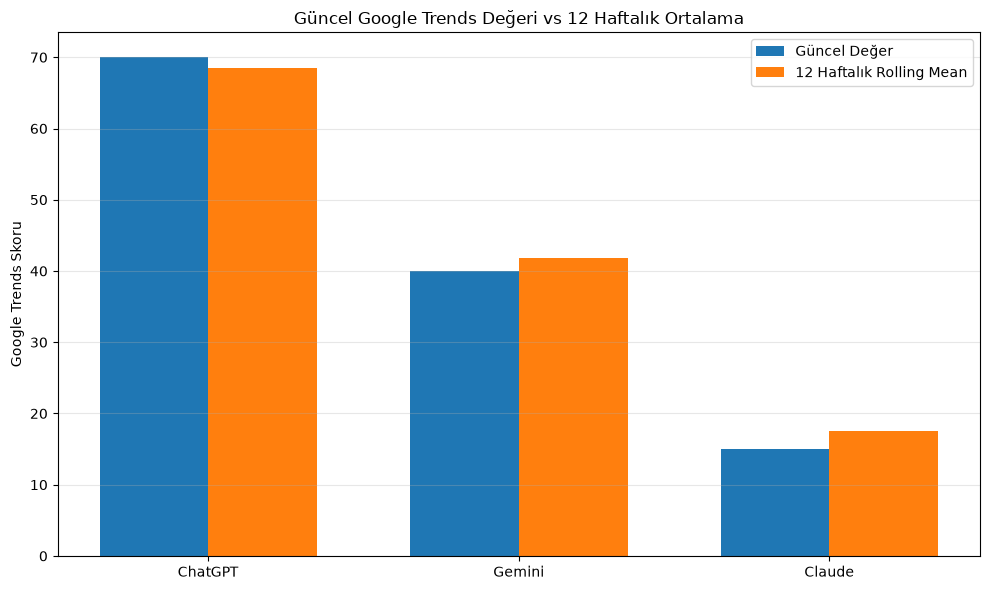

In [41]:
# --------------------------------------------------
# Güncel değer ve rolling mean karşılaştırması
# --------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np


# current_monitoring tablosunda her trend için:
#
# Trend
# Current_Value
# Rolling_Mean
# Anomaly_Score
# Is_Anomaly
#
# bilgileri bulunuyor.


# Grafikte X ekseninde üç trend olacak.
trend_names = current_monitoring["Trend"]


# Her trendin en güncel gerçek Google Trends değerini alıyoruz.
current_values = current_monitoring["Current_Value"]


# Her trendin önceki 12 haftalık ortalama seviyesini alıyoruz.
rolling_means = current_monitoring["Rolling_Mean"]


# --------------------------------------------------
# Barların X eksenindeki konumlarını oluşturma
# --------------------------------------------------

# np.arange(3) bize:
#
# [0, 1, 2]
#
# değerlerini verir.
#
# Bu konumlar sırasıyla:
# ChatGPT, Gemini ve Claude'u temsil edecek.
x_positions = np.arange(
    len(trend_names)
)


# Her barın genişliği.
bar_width = 0.35


# Grafik alanını oluşturuyoruz.
plt.figure(
    figsize=(10, 6)
)


# --------------------------------------------------
# Güncel değer barları
# --------------------------------------------------

# Barları biraz sola kaydırıyoruz.
#
# Böylece aynı trend için Current ve Rolling Mean
# yan yana görünecek.
plt.bar(
    x_positions - bar_width / 2,
    current_values,
    width=bar_width,
    label="Güncel Değer",
)


# --------------------------------------------------
# Rolling Mean barları
# --------------------------------------------------

# Rolling mean barlarını biraz sağa kaydırıyoruz.
plt.bar(
    x_positions + bar_width / 2,
    rolling_means,
    width=bar_width,
    label="12 Haftalık Rolling Mean",
)


# --------------------------------------------------
# X eksenindeki 0, 1, 2 sayılarını
# gerçek trend adlarıyla değiştiriyoruz.
# --------------------------------------------------

plt.xticks(
    x_positions,
    trend_names,
)


# Grafik başlığı
plt.title(
    "Güncel Google Trends Değeri vs 12 Haftalık Ortalama"
)


# Y ekseninin neyi gösterdiğini belirtiyoruz.
plt.ylabel(
    "Google Trends Skoru"
)


# Barların açıklamasını gösteriyoruz.
plt.legend()


# Arka planda yatay yardımcı çizgiler.
plt.grid(
    axis="y",
    alpha=0.3,
)


# Grafik öğelerinin birbirine girmesini engeller.
plt.tight_layout()


# Grafiği gösterir.
plt.show()

### Trend Serileri Üzerinde Anomaly Noktalarının Görselleştirilmesi

ChatGPT, Gemini ve Claude için anomaly detection sonuçları zaman serisi üzerinde
görselleştirilecektir.

Her grafik üzerinde:

- gerçek Google Trends serisi,
- 12 haftalık rolling mean,
- anomaly olarak tespit edilen haftalar

birlikte gösterilecektir.

Anomaly noktalarının yanında ilgili `Anomaly_Score` değeri de gösterilecektir.

Bu grafikler sayesinde detector'ın hangi trend hareketlerini olağan dışı olarak
işaretlediği zaman serisinin genel davranışı içerisinde incelenebilir.

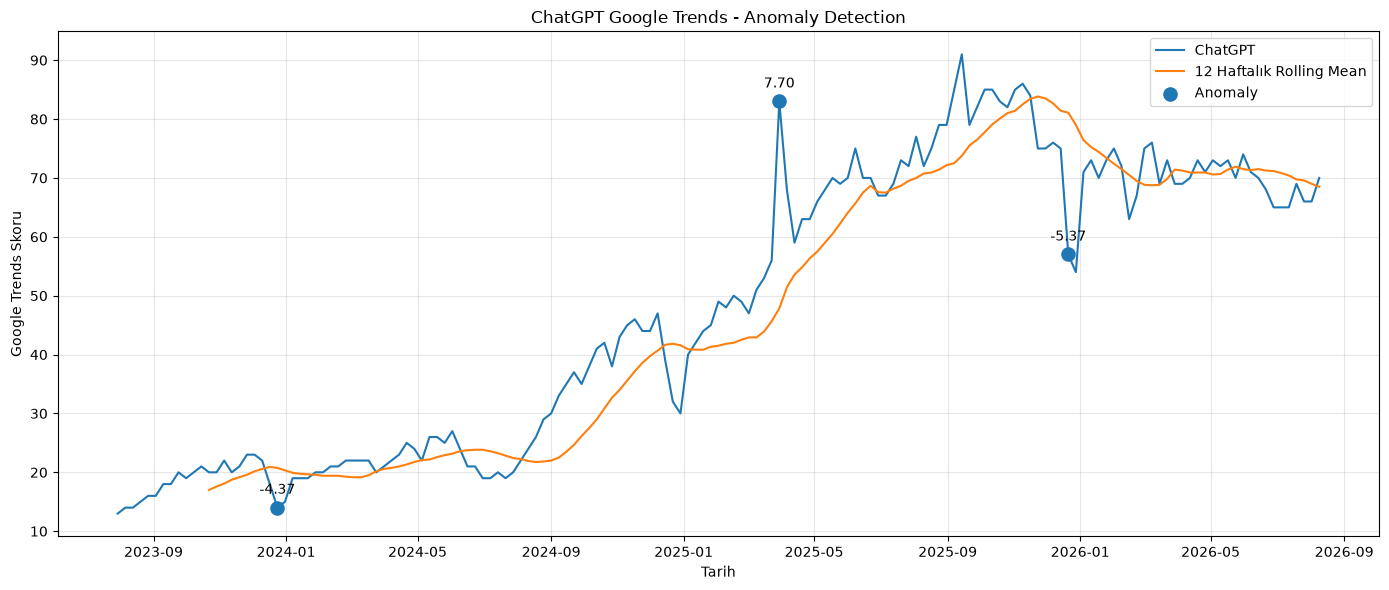

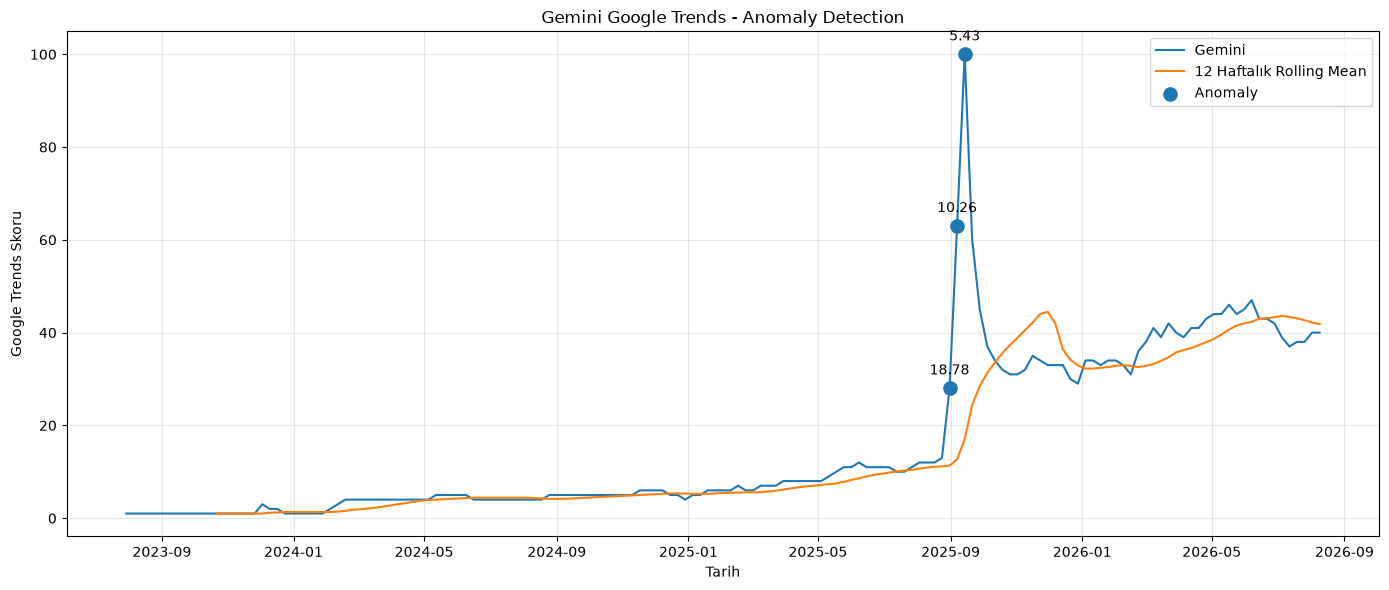

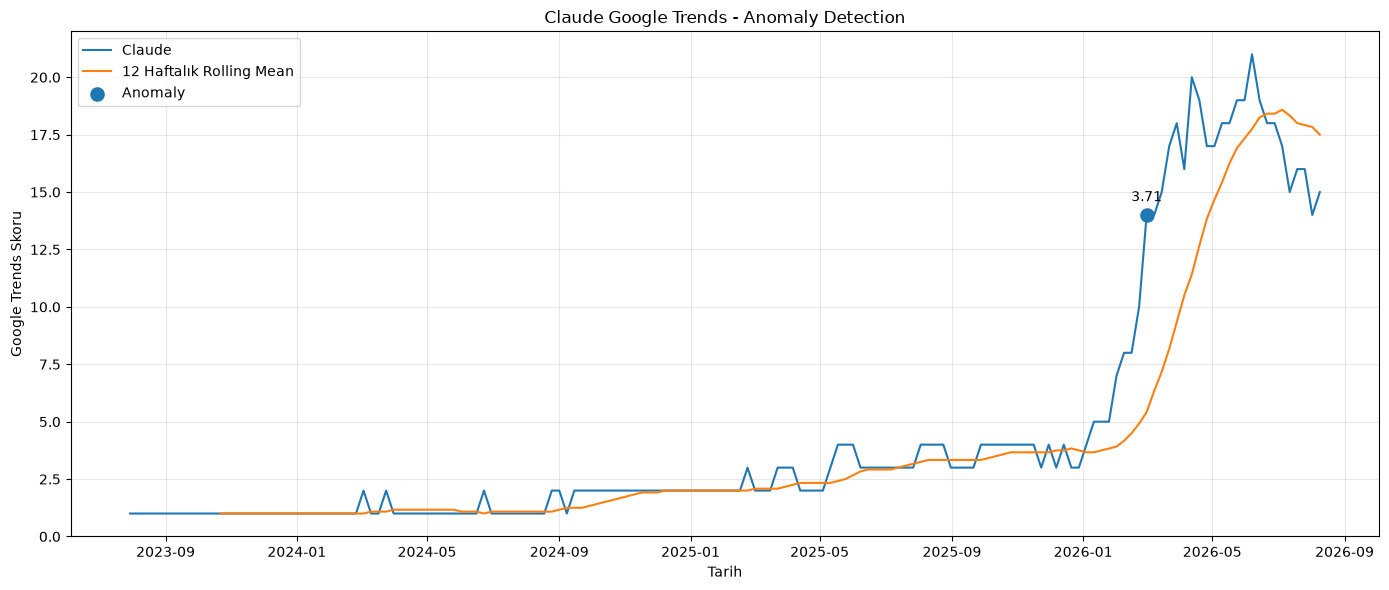

In [42]:
# --------------------------------------------------
# Üç trend için anomaly grafiklerini çizme
# --------------------------------------------------

import matplotlib.pyplot as plt


# Daha önce oluşturduğumuz:
#
# all_anomaly_results["ChatGPT"]
# all_anomaly_results["Gemini"]
# all_anomaly_results["Claude"]
#
# yapısının içinde her trendin:
#
# - gerçek değeri
# - rolling mean'i
# - anomaly score'u
# - Is_Anomaly sonucu
#
# bulunuyor.


# .items():
# dictionary içindeki trendleri tek tek dolaşır.
#
# Her döngüde:
#
# trend_name -> "ChatGPT", "Gemini" veya "Claude"
# result     -> o trende ait anomaly DataFrame'i
for trend_name, result in all_anomaly_results.items():

    # --------------------------------------------------
    # Sadece anomaly olan haftaları seçme
    # --------------------------------------------------

    # Is_Anomaly == True olan satırları seçiyoruz.
    #
    # Örneğin Gemini için burada:
    #
    # 2025-08-31
    # 2025-09-07
    # 2025-09-14
    #
    # gibi detector'ın alarm verdiği haftalar kalacak.
    anomalies = result.loc[
        result["Is_Anomaly"]
    ]


    # --------------------------------------------------
    # Yeni grafik oluşturma
    # --------------------------------------------------

    # Her trend için AYRI bir grafik oluşturuyoruz.
    #
    # Döngü 3 kez çalışacağı için:
    #
    # 1. grafik -> ChatGPT
    # 2. grafik -> Gemini
    # 3. grafik -> Claude
    plt.figure(
        figsize=(14, 6)
    )


    # --------------------------------------------------
    # Gerçek Google Trends serisini çizme
    # --------------------------------------------------

    # result["Value"]:
    # O haftadaki gerçek Google Trends değeridir.
    #
    # result.index:
    # Tarihleri temsil eder.
    plt.plot(
        result.index,
        result["Value"],
        label=trend_name,
    )


    # --------------------------------------------------
    # 12 haftalık rolling mean'i çizme
    # --------------------------------------------------

    # Rolling_Mean:
    # Her hafta için o haftadan ÖNCEKİ
    # 12 haftanın ortalama seviyesidir.
    #
    # Detector bu değeri yakın geçmişteki
    # "normal seviye" olarak kullanıyor.
    plt.plot(
        result.index,
        result["Rolling_Mean"],
        label="12 Haftalık Rolling Mean",
    )


    # --------------------------------------------------
    # Anomaly noktalarını işaretleme
    # --------------------------------------------------

    # scatter():
    # Çizgi yerine tek tek noktalar oluşturur.
    #
    # Burada sadece anomaly olarak tespit edilen
    # tarihleri işaretliyoruz.
    plt.scatter(
        anomalies.index,
        anomalies["Value"],

        # Noktaları daha görünür hale getiriyoruz.
        s=90,

        label="Anomaly",

        # Noktaların çizginin önünde görünmesini sağlar.
        zorder=5,
    )


    # --------------------------------------------------
    # Anomaly Score değerlerini noktaların yanına yazma
    # --------------------------------------------------

    # iterrows():
    # anomaly satırlarını tek tek dolaşır.
    #
    # date:
    # anomaly tarihi
    #
    # row:
    # o tarihe ait bütün sütunları içerir.
    for date, row in anomalies.iterrows():

        # annotate():
        # Grafikte belirli bir noktanın yanına
        # açıklama yazmamızı sağlar.
        plt.annotate(

            # :.2f
            # Anomaly Score'u virgülden sonra
            # 2 basamakla gösterir.
            #
            # Örneğin:
            # 18.776690 -> 18.78
            f'{row["Anomaly_Score"]:.2f}',

            # Yazının hangi noktaya ait olduğunu
            # belirtiyoruz.
            xy=(
                date,
                row["Value"],
            ),

            # Yazıyı noktanın biraz üzerine taşıyoruz.
            #
            # xytext=(0, 10):
            # yatayda 0,
            # dikeyde 10 birim yukarı.
            xytext=(0, 10),

            # xytext değerlerinin ekran üzerindeki
            # nokta cinsinden yorumlanmasını sağlar.
            textcoords="offset points",

            # Yazıyı noktanın ortasına hizalar.
            ha="center",
        )


    # --------------------------------------------------
    # Grafik başlığı ve eksenler
    # --------------------------------------------------

    plt.title(
        f"{trend_name} Google Trends - Anomaly Detection"
    )

    plt.xlabel(
        "Tarih"
    )

    plt.ylabel(
        "Google Trends Skoru"
    )


    # Çizgilerin ve anomaly noktalarının
    # açıklamalarını gösterir.
    plt.legend()


    # Grafiğin okunmasını kolaylaştıran
    # yardımcı grid çizgileri.
    plt.grid(
        alpha=0.3
    )


    # Grafik öğelerinin birbirine girmesini önler.
    plt.tight_layout()


    # Mevcut trendin grafiğini gösterir.
    #
    # Döngünün sonraki turunda yeni bir
    # plt.figure() oluşturulacağı için
    # her trend ayrı grafik olarak çıkacaktır.
    plt.show()

İlk kısmı doğru anlamışsın, sadece **`7.70` kısmında önemli bir ayrım var**.

Grafikteki anomaly noktalarını şöyle okumalıyız:

### 1. İlk anomaly: `-4.37`

Bu noktada ChatGPT değeri:

```text
Gerçek değer      = 14
12 haftalık ort.  = 20.75
Fark              = 14 - 20.75
                  = -6.75 puan
```

Yani evet, ChatGPT ilgisi önceki 12 haftanın ortalamasına göre **beklenmedik derecede düşük**.

Ama:

```text
Anomaly Score = -4.37
```

demek **4.37 puan düşük** demek değil.

Şu demek:

> Değer, yakın geçmişteki normal seviyeden yaklaşık **4.37 standart sapma aşağıda**.

---

### 2. Ortadaki büyük anomaly: `+7.70`

Burada:

```text
Gerçek değer      = 83
12 haftalık ort.  ≈ 47.83

Gerçek puan farkı:
83 - 47.83 ≈ +35.17
```

Yani trend **beklenen seviyeyi yaklaşık 35 Google Trends puanı aşmış**.

Grafikte yazan:

```text
7.70
```

ise:

> Bu +35 puanlık fark, geçmişteki normal oynaklığa göre yaklaşık **7.7 standart sapmalık sıra dışı bir yükseliş**.

Dolayısıyla **“7 puan beklentiyi aşmış” değil**.

Doğru ayrım:

```text
Absolute Change → Kaç Google Trends puanı fark var?

Anomaly Score → Bu fark geçmişteki normal
                oynaklığa göre ne kadar sıra dışı?
```

Mesela ortadaki noktada:

```text
Absolute Change ≈ +35.17 puan
Anomaly Score   ≈ +7.70 standart sapma
```

Son noktada da:

```text
Gerçek değer     = 57
Rolling Mean     ≈ 81.08
Fark             ≈ -24.08 puan
Anomaly Score    ≈ -5.37
```

Yani yaklaşık **24 puanlık beklenmedik düşüş**, geçmişteki oynaklığa göre **5.37 standart sapma aşağıda**.

Kısacası grafikte noktaların üstündeki `-4.37`, `7.70`, `-5.37` değerlerini **puan farkı değil, “ne kadar sıra dışı?” ölçüsü** olarak oku. Puan farkını görmek istiyorsan `Absolute_Change` sütununa bakıyoruz.
